### Graduate Trainee Technical Assessment - Mukundi Ramanyimi

# Customer Intelligence Platform — Customer Segmentation & Personalisation System

### Business Case


RetailCore Bank is a mid-sized retail bank serving over 2 million customers across multiple product lines including transactional accounts, credit cards, personal loans, and savings products. Like most retail banks, RetailCore faces a significant challenge: although customer data is abundant, the bank struggles to translate it into personalised experiences that drive engagement and retention.


The bank’s marketing team currently sends the same product campaigns to all customers regardless of behaviour, lifecycle stage, or financial profile. This results in:

• Low campaign conversion rates due to irrelevant product offers

• Customer churn from high-value segments who feel underserved

• Missed cross-sell and upsell opportunities worth an estimated R180M annually

• Executive leadership lacking clear visibility into customer segmentation health


To address this, the AI Engineering team has been tasked with building a proof-of-concept Customer Intelligence Platform. The platform must segment customers into meaningful behavioural clusters, generate personalised product recommendations, and surface AI-generated explanations that non-technical executives can act on.


As a new member of the team, you are being asked to independently build this proof-of-concept end-to-end.



### Project Overview
This notebook implements an end-to-end customer segmentation and product 
recommendation system for a fictional South African retail bank. 

The system:
- Generates 2000 synthetic but realistic banking customers using controlled 
  statistical distributions
- Performs exploratory data analysis with validation, cleaning and visualisation
- Applies KMeans clustering with PCA dimensionality reduction to identify 
  4 distinct customer segments
- Recommends personalised bank products for each segment based on financial 
  eligibility and ownership gap analysis
- Predicts the segment and recommended products for new customers in real time
- Generates natural language segment summaries using the Google Gemini API

### Reproducibility
All random processes use a fixed seed (numpy.random.seed(42)) to ensure 
fully reproducible results.


# 1. DATA GENERATION

For the dataset, the given customer features make the dataset realistic, but I decided to add further features to make the dataset robust. Features such as marital_status, customer_id, and gender. I used Anthropic Claude to write the dataset.

## Prompt:

I am building a customer segmentation and personalisation system for a fictional bank as part of a customer intelligence platform project. I need you to generate a realistic synthetic dataset of 600 bank customers that will later be used for machine learning tasks, specifically unsupervised clustering to segment customers, product recommendation based on cluster profiles.

The data must be as realistic as possible, features should not be independent of each other. There should be meaningful correlations between them. For example, income should influence which products a customer holds.

The dataset should include these features:

Identifiers: customer_id, first_name, last_name — use South African names and a simple ID format like CUST-00001. No real ID numbers - Might have a conflict.
Demographic: age, gender, marital_status, number_of_dependents, education_level, province, employment_status
Financial: monthly_income, income_band, monthly_expenses, account_tenure_years
Behavioural: monthly_transactions, avg_transaction_value, digital_login_frequency, branch_visit_count, late_payment_count
Product: has_savings_account, has_credit_card, has_home_loan, has_personal_loan, has_vehicle_finance, has_investment_account, active_products_count
Risk: credit_score, loan_utilisation_rate, days_since_last_default
Target: churn_risk_label (Low / Medium / High)

You can also add other features that you think are relevant.

I do not want you to produce a CSV file directly. Instead, I want you to write me the Python code that generates this dataset. The code should include comments explaining the reasoning behind the key correlation decisions so I can understand the choices.


The data generation script, written by  Claude, is in /data/data_generation.py

In [3]:
# Generate synthetic bank customer dataset

from data.data_generation import generate_synthetic_bank_customers
generate_synthetic_bank_customers(N=2000, OUTPUT_PATH="data/bank_customers.csv")


✓ Dataset saved to 'data/bank_customers.csv'


# 2. EXPLOLATORY DATA ANALYSIS

In this section, we perform exploratory data analysis. This process involves cleaning the data to remove inconsistencies, validating its accuracy, and uncovering meaningful patterns. Ensuring high data quality is essential, as it directly impacts the effectiveness of clustering.

In [4]:
# Import pandas and numpy for data manipulation

import pandas as pd
import numpy as np

# Import matplotlib and seaborn for visualization
 
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
# Load the data

df = pd.read_csv("data/bank_customers.csv")


##  2.1. Inspection

Inspect the data.

In [6]:
# Validate the data shape
df.shape

(2000, 49)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 49 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   customer_id                           2000 non-null   str    
 1   first_name                            2000 non-null   str    
 2   last_name                             2000 non-null   str    
 3   age                                   2000 non-null   int64  
 4   gender                                2000 non-null   str    
 5   marital_status                        2000 non-null   str    
 6   number_of_dependents                  2000 non-null   int64  
 7   education_level                       2000 non-null   str    
 8   province                              2000 non-null   str    
 9   employment_status                     2000 non-null   str    
 10  monthly_income                        2000 non-null   float64
 11  income_band                 

In [8]:
# Preview the data
df.head()

,customer_id,first_name,last_name,age,gender,marital_status,number_of_dependents,education_level,province,employment_status,...,has_revolving_loan,has_overdraft,has_investment_backed_lending,has_student_loan,has_fixed_deposit,has_tax_free_savings,credit_score,loan_utilisation_rate,days_since_last_default,churn_risk_label
0,CUST-00001,Mihlali,Mthembu,33,Female,Single,1,Degree,Eastern Cape,Employed,...,0,0,0,0,0,1,527,0.596,228,Low
1,CUST-00002,Thabo,Nxumalo,25,Male,Single,0,Degree,Gauteng,Employed,...,0,0,0,0,0,0,583,0.451,9999,Medium
2,CUST-00003,Sipho,Daniels,36,Male,Married,0,No Matric,Gauteng,Self-Employed,...,0,0,0,0,0,0,589,0.000,493,Medium
3,CUST-00004,Jade,Pillay,37,Female,Single,0,Postgraduate,KwaZulu-Natal,Employed,...,1,1,0,0,0,0,742,0.436,725,Low
4,CUST-00005,Mihlali,Daniels,35,Female,Married,3,Matric,Eastern Cape,Unemployed,...,0,0,0,0,0,0,407,0.000,339,High


In [9]:
# Check numeric ranges
df.describe()

,age,number_of_dependents,monthly_income,monthly_expenses,account_tenure_years,monthly_transactions,avg_transaction_value,digital_login_frequency,branch_visit_count,late_payment_count,...,has_term_loan,has_revolving_loan,has_overdraft,has_investment_backed_lending,has_student_loan,has_fixed_deposit,has_tax_free_savings,credit_score,loan_utilisation_rate,days_since_last_default
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.00000,...,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,37.319500,1.135000,19032.368235,11739.400000,5.914250,22.8350,514.223455,13.971500,3.580000,2.06150,...,0.193000,0.02200,0.023000,0.015500,0.008000,0.047000,0.039000,587.52000,0.328276,4543.278500
std,11.508547,1.277337,19649.299433,11755.215446,3.295884,15.0438,414.547469,6.744066,2.093751,1.83232,...,0.394752,0.14672,0.149941,0.123561,0.089107,0.211692,0.193643,83.15373,0.238196,4515.839622
min,18.000000,0.000000,0.000000,0.000000,0.500000,3.0000,50.000000,0.000000,0.000000,0.00000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,300.00000,0.000000,10.000000
25%,29.000000,0.000000,4500.000000,3100.000000,3.500000,12.0000,216.552500,9.000000,2.000000,1.00000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,535.00000,0.000000,456.000000
50%,34.000000,1.000000,12400.000000,8000.000000,5.800000,20.0000,448.545000,14.000000,3.000000,2.00000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,595.00000,0.380000,1639.500000
75%,44.000000,2.000000,27200.000000,16100.000000,8.100000,31.0000,702.437500,18.000000,5.000000,3.00000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,644.00000,0.504000,9999.000000
max,75.000000,6.000000,126200.000000,90300.000000,19.000000,103.0000,4107.110000,38.000000,13.000000,10.00000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,805.00000,0.950000,9999.000000


## 2.2. Missing Values and Data Types

In this subsection, we check for missing data values and validate the data types.

In [10]:
# Check basic data structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 49 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   customer_id                           2000 non-null   str    
 1   first_name                            2000 non-null   str    
 2   last_name                             2000 non-null   str    
 3   age                                   2000 non-null   int64  
 4   gender                                2000 non-null   str    
 5   marital_status                        2000 non-null   str    
 6   number_of_dependents                  2000 non-null   int64  
 7   education_level                       2000 non-null   str    
 8   province                              2000 non-null   str    
 9   employment_status                     2000 non-null   str    
 10  monthly_income                        2000 non-null   float64
 11  income_band                 

In [11]:
# Check for missing values
df.isnull().sum()

customer_id                             0
first_name                              0
last_name                               0
age                                     0
gender                                  0
marital_status                          0
number_of_dependents                    0
education_level                         0
province                                0
employment_status                       0
monthly_income                          0
income_band                             0
monthly_expenses                        0
account_tenure_years                    0
monthly_transactions                    0
avg_transaction_value                   0
digital_login_frequency                 0
branch_visit_count                      0
late_payment_count                      0
preferred_channel                       0
has_savings_account                     0
has_credit_card                         0
has_home_loan                           0
has_personal_loan                 

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
# Validate Categorical values
df["gender"].unique(), df["marital_status"].unique(), df["education_level"].unique(), df["employment_status"].unique()

(<StringArray>
 ['Female', 'Male']
 Length: 2, dtype: str,
 <StringArray>
 ['Single', 'Married', 'Divorced', 'Widowed']
 Length: 4, dtype: str,
 <StringArray>
 ['Degree', 'No Matric', 'Postgraduate', 'Matric', 'Diploma']
 Length: 5, dtype: str,
 <StringArray>
 ['Employed', 'Self-Employed', 'Unemployed', 'Retired', 'Student']
 Length: 5, dtype: str)

### Summary

- No null values were found across all the columns. 
- Data types are correct for all features. 
- For all the numerical features, the value ranges fall within the expected bounds. 
- There are no duplicates. All categorical features have correct options.

Consistent with the controlled data generation process.

## 2.3. Outlier Detection

We use the Interquartile Range (IQR) method to detect outliers in the numerical data. To visualize these outliers, we employ boxplots, which are particularly effective for this purpose. Boxplots clearly display the median, quartiles, and potential outliers, making them the most suitable visualization tool for understanding the spread of the data and spotting unusual values.



/var/folders/94/0d9135bx17185spr24txkrmc0000gn/T/ipykernel_48114/4175981445.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = axes[idx].boxplot(
/var/folders/94/0d9135bx17185spr24txkrmc0000gn/T/ipykernel_48114/4175981445.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = axes[idx].boxplot(
/var/folders/94/0d9135bx17185spr24txkrmc0000gn/T/ipykernel_48114/4175981445.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = axes[idx].boxplot(
/var/folders/94/0d9135bx17185spr24txkrmc0000gn/T/ipykernel_48114/4175981445.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation

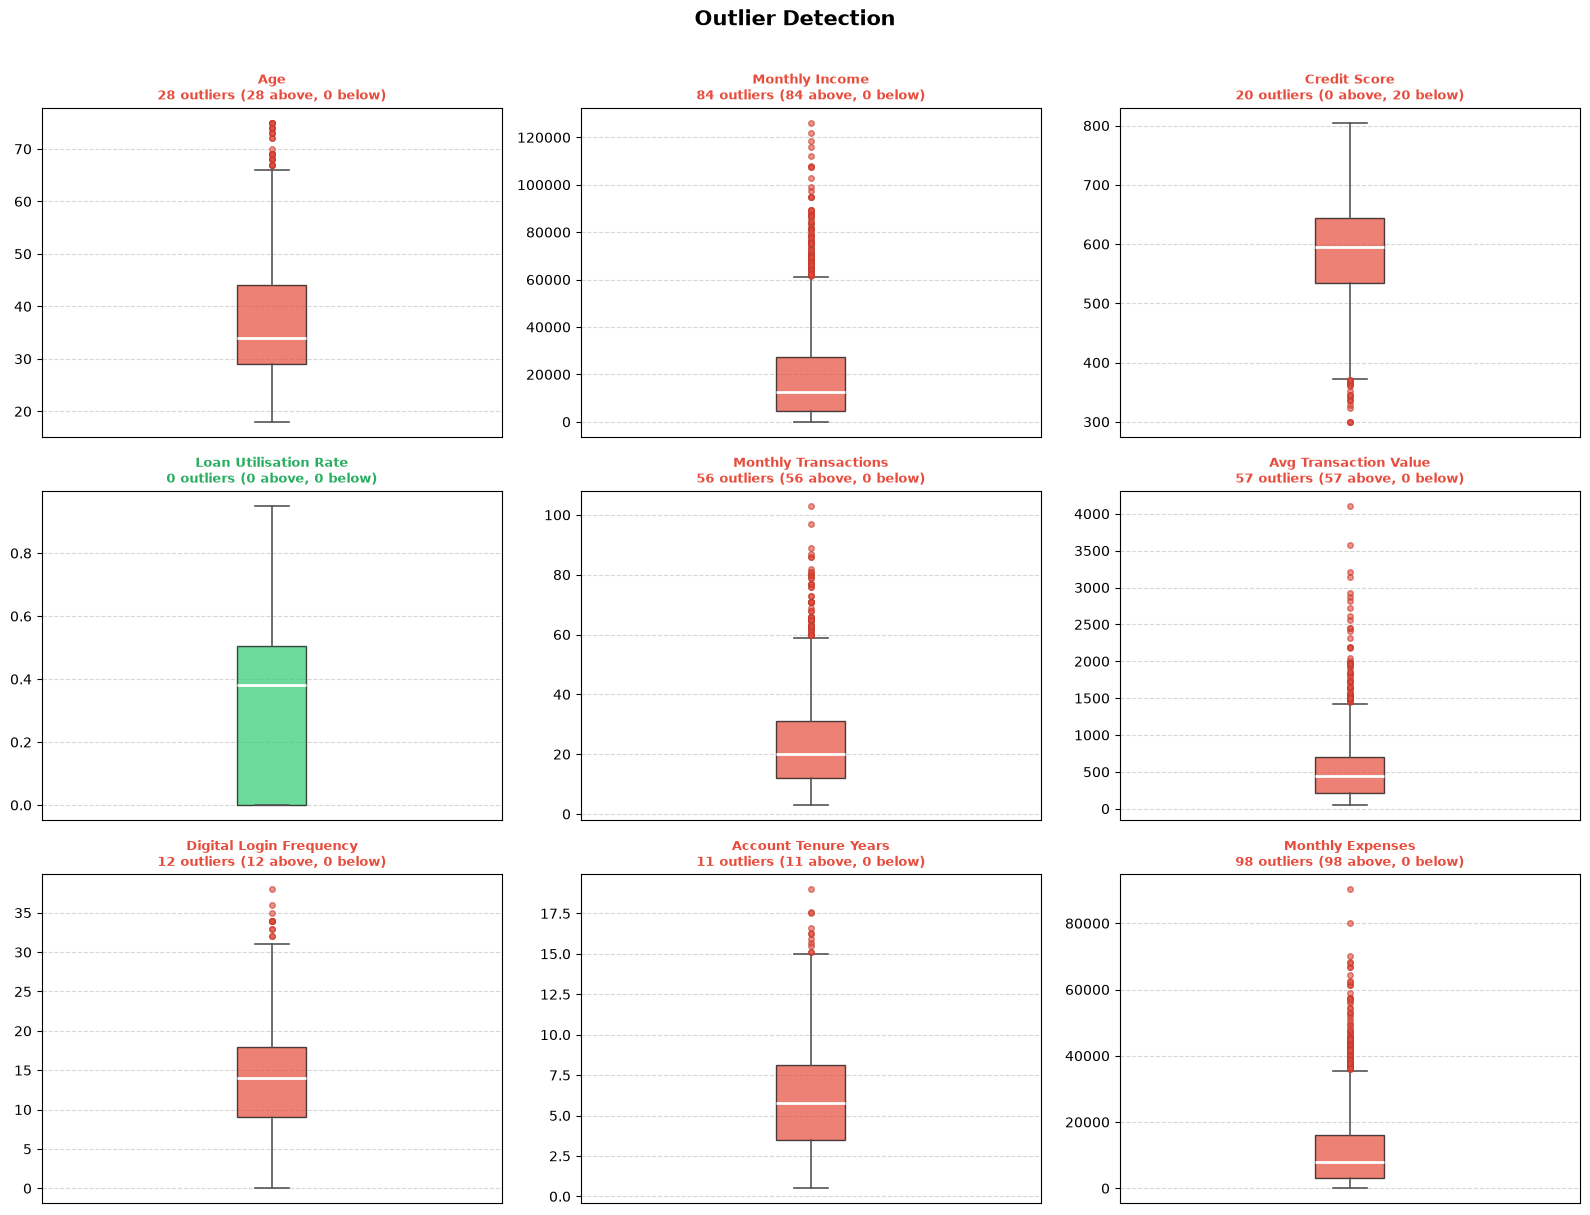

In [14]:
# Visualie the distributions and outliers using boxplots
outlier_cols = [
    'age', 'monthly_income', 'credit_score',
    'loan_utilisation_rate', 'monthly_transactions', 'avg_transaction_value',
    'digital_login_frequency', 'account_tenure_years', 'monthly_expenses'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(outlier_cols):
    
    # IQR
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    
    n_upper = (df[col] > upper_bound).sum()
    n_lower = (df[col] < lower_bound).sum()
    n_total = n_upper + n_lower
    
    # Colour the box red if outliers exist, green if clean
    box_color = "#e74c3c" if n_total > 0 else "#2ecc71"
    
    bp = axes[idx].boxplot(
        df[col].dropna(),
        vert=True,
        patch_artist=True,          # Filled boxes
        flierprops=dict(
            marker='o',
            markerfacecolor='#e74c3c',
            markeredgecolor='#c0392b',
            markersize=4,
            alpha=0.6,
            linestyle='none'
        ),
        medianprops=dict(color='white', linewidth=2),
        boxprops=dict(facecolor=box_color, alpha=0.7),
        whiskerprops=dict(color='#555555', linewidth=1.2),
        capprops=dict(color='#555555', linewidth=1.2)
    )
    
    # Title with outlier count
    axes[idx].set_title(
        f"{col.replace('_', ' ').title()}\n"
        f"{n_total} outlier{'s' if n_total != 1 else ''} "
        f"({n_upper} above, {n_lower} below)",
        fontsize=9.5,
        fontweight='bold',
        color='#e74c3c' if n_total > 0 else '#27ae60'
    )
    
    axes[idx].set_xticks([])
    axes[idx].yaxis.grid(True, linestyle='--', alpha=0.5)
    axes[idx].set_axisbelow(True)
    
    # # Annotate the upper bound line
    # axes[idx].axhline(
    #     y=upper_bound,
    #     color='navy', linestyle='--',
    #     linewidth=0.9, alpha=0.6
    # )
    # if lower_bound > df[col].min():
    #     axes[idx].axhline(
    #         y=lower_bound,
    #         color='navy', linestyle='--',
    #         linewidth=0.9, alpha=0.6
    #     )

plt.suptitle(
    "Outlier Detection",
    fontsize=15, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.show()

Outliers were detected in several numerical features using the IQR method, mostly on the upper-end values representing high-income, high-activity customer segments. These are not data errors. Hence, the outliers were not removed as they represent genuine customer behaviour. This will be attended to during preprocessing, as this informs our scaling method. Because of these outliers, we will use RobustScaler during preprocessing.

## 2.4. Categorical Distribution

In this subsection, we examine the distribution of the categorical data.

In [15]:
categorical_cols = [
    'income_band', 'employment_status', 'province', 
    'marital_status', 'education_level', 'preferred_channel', 
    'churn_risk_label'
]

for col in categorical_cols:
    print(f"\n")
    print(df[col].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')



income_band
LSM 1-4           36.0%
LSM 5-6           30.0%
LSM 7-8           19.6%
Affluent          12.8%
High Net Worth     1.6%
Name: proportion, dtype: str


employment_status
Employed         58.9%
Unemployed       17.8%
Self-Employed    14.4%
Retired           6.7%
Student           2.2%
Name: proportion, dtype: str


province
Gauteng          25.3%
KwaZulu-Natal    19.0%
Western Cape     13.1%
Limpopo          11.4%
Eastern Cape     10.8%
Mpumalanga        8.9%
North West        6.6%
Free State        3.6%
Northern Cape     1.4%
Name: proportion, dtype: str


marital_status
Married     49.8%
Single      44.0%
Divorced     5.4%
Widowed      0.8%
Name: proportion, dtype: str


education_level
Matric          32.8%
Diploma         26.1%
Degree          22.1%
No Matric       11.2%
Postgraduate     7.8%
Name: proportion, dtype: str


preferred_channel
Digital-Preferred    63.6%
Branch-Preferred     18.6%
Passive              12.8%
Digital-Only          5.0%
Name: proportion, dtype

Note: LSM here is the Living Standard Measure (LSM), a South African consumer segmentation tool developed by SAARF (South African Audience Research Foundation) that classifies people from LSM 1 (lowest) to LSM 10 (highest) based on household assets and access to services rather than just income.

## 2.5. Preprocessing for Days since last default

During data generation, Claude assigned the value 9999 to customers who have never defaulted in the days_since_last_default feature. In this section, we explore ways to appropriately address this placeholder value.

In [16]:
# Check the range and counts of 'days_since_last_default'
df['days_since_last_default'].value_counts().sort_index()

days_since_last_default
10       12
11        1
12        1
13        2
14        1
       ... 
3500      1
3635      1
3640      1
3650     30
9999    802
Name: count, Length: 832, dtype: int64

In [17]:
# Check how many customers have 9999 days since last default (indicating no defaults)
(df['days_since_last_default'] == 9999).sum()

np.int64(802)

#### Handling the Value 9999 

During data generation, Claude assigned the value 9999 to customers who have never defaulted on their payments in the days_since_last_default feature. Importantly, this value does not indicate that a customer last defaulted 9,999 days ago; rather, it serves as a placeholder.

One possible approach is to replace the 9999 value with a large but realistic number (e.g., 2000). However, this introduces inaccuracy, since these customers have never defaulted at all.

A more effective solution is to introduce a binary flag that indicates whether a customer has ever defaulted. This approach is cleaner, more interpretable, and avoids any loss of information, while ensuring that the dataset accurately reflects customer behavior.

In [18]:
# Create a new feature that indicates whether a customer has ever defaulted
df['has_ever_defaulted'] = (df['days_since_last_default'] != 9999).astype(int)
df['days_since_last_default'] = df['days_since_last_default'].replace(999, 0)



## 2.6. Correlations

In this section, we examine whether the correlations defined during the data generation process are present and accurate. For example, we expect to observe a positive correlation between education level and monthly income.

In [19]:
# Verify relationships. CCheck if there is a positive correlation between education level and monthly income.

# Check that education has influence on income
df.groupby("education_level")["monthly_income"].mean().sort_values()

# Postgraduate > Degree > Diploma > Matric > No matric 

education_level
No Matric        3846.561839
Matric           6988.763470
Diploma         15845.655690
Degree          33969.809457
Postgraduate    59802.868782
Name: monthly_income, dtype: float64

In [20]:
# Chrck that late payments has influence on credit score
df.groupby("late_payment_count")["credit_score"].mean().sort_values()

# Late payment counts have low credit scores

late_payment_count
9     300.000000
10    300.000000
8     360.200000
7     402.950000
6     425.232143
5     477.787402
4     516.034653
3     554.062914
2     590.899721
1     625.060185
0     666.241736
Name: credit_score, dtype: float64

In [21]:
# Check that older people have had their accounts for longer

df.groupby("age")["account_tenure_years"].mean().sort_values()

age
18    1.100000
20    1.825000
19    2.043750
21    2.507143
67    2.875000
22    2.989655
24    3.347222
23    3.639535
25    3.932143
59    4.566667
68    4.640000
44    4.957895
73    5.066667
65    5.250000
63    5.484615
36    5.655556
74    5.675000
26    5.696610
55    5.727778
47    5.735294
27    5.845763
75    5.850000
43    5.882051
46    5.930769
28    5.938961
56    5.980000
66    5.980000
49    6.038462
50    6.081818
31    6.103488
39    6.120000
60    6.165000
70    6.200000
69    6.220000
53    6.232143
61    6.266667
30    6.271277
51    6.348148
38    6.370833
62    6.388889
34    6.413402
45    6.491892
29    6.496512
37    6.576667
57    6.618750
41    6.636170
58    6.661538
33    6.662745
40    6.674138
52    6.839286
32    6.886598
35    6.940260
72    6.950000
48    6.958824
64    7.292308
54    7.456522
42    8.278125
Name: account_tenure_years, dtype: float64

In [22]:
# Income VS Expense ratio
(df["monthly_expenses"] / df["monthly_income"]).describe()

count    1989.000000
mean        0.684923
std         0.181635
min         0.000000
25%         0.554017
50%         0.646643
75%         0.748031
max         1.974334
dtype: float64

In [23]:
# Check for features that affect churn risk. Check if the correlations are positive or negative with churn risk.
df.groupby("churn_risk_label")[["credit_score","loan_utilisation_rate","late_payment_count","active_products_count","digital_login_frequency"]].mean()

,credit_score,loan_utilisation_rate,late_payment_count,active_products_count,digital_login_frequency
churn_risk_label,,,,,
High,525.305000,0.202063,3.0175,1.037500,12.180000
Low,632.402000,0.401768,1.4610,3.828000,15.312000
Medium,554.193333,0.289933,2.4250,1.481667,12.931667


- Customers with high credit scores have a lower churn risk (i.e., they are less likely to leave the bank’s services) compared to those with low credit scores.

- Customers who make greater use of their loans are less likely to discontinue the bank’s services.

- Customers with a high number of late payments are more likely to leave the bank.

- Customers who hold multiple bank products and frequently use digital login services are less likely to churn.

## 2.7. Visualizations

In this section, we visually explore the relationships between different data features.

### 2.7.1 Monthly Income Distribution

Plot the monthly income distribution. We should see a right skewed distribution with a long taiL. 
Average income should be around 25k, with most people earning below 10k

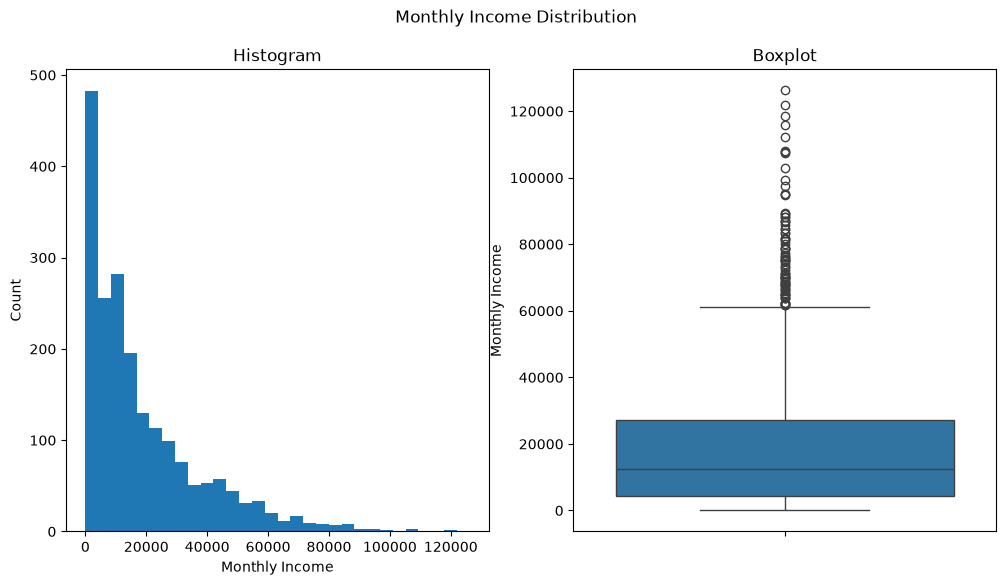

In [24]:
fig,ax = plt.subplots(1,2, figsize=(12,6))


ax[0].hist(df["monthly_income"], bins=30)
ax[0].set_title("Histogram")
ax[0].set_xlabel("Monthly Income")
ax[0].set_ylabel("Count")

sns.boxplot(y=df["monthly_income"], ax=ax[1])
ax[1].set_title("Boxplot")
ax[1].set_ylabel("Monthly Income")
# ax[1].set_xticks(rotation=45)

plt.suptitle("Monthly Income Distribution")



plt.show()

### 2.7.2 Monthly Income by Education Level

Visualize the relationship between education level and monthly income using a boxplot. We should see a clear increase in median income as education level increases, with postgraduate having the highest median income and no matric having the lowest.

We use boxplots as we are comparing catorigical variable (education level) with a numeric variable (monthly income). Boxplots show the median, quartiles, and potential outliers, which is ideal for understanding the distribution of income across different education levels. 

/var/folders/94/0d9135bx17185spr24txkrmc0000gn/T/ipykernel_48114/846282913.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="education_level", y="monthly_income", data=df,


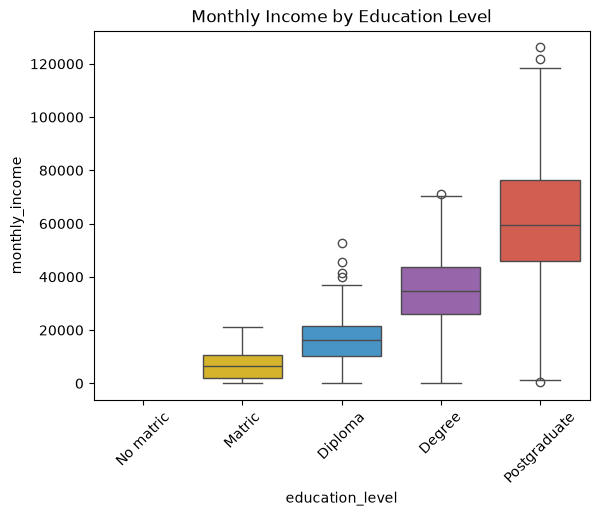

In [25]:
sns.boxplot(x="education_level", y="monthly_income", data=df, 
            order=["No matric", "Matric", "Diploma", "Degree", "Postgraduate"],
            palette={"No matric":"#2ecc71", "Matric":"#f1c40f", "Diploma":"#3498db", "Degree":"#9b59b6", "Postgraduate":"#e74c3c"})
plt.title("Monthly Income by Education Level")
plt.xticks(rotation=45)
plt.show()

We can also use a bar graph, but it will only show the mean income for each education level, without providing insights into the distribution or variability of income within each group. Boxplots provide a more comprehensive view of the data, making them more suitable for this analysis.


(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Degree'),
  Text(1, 0, 'Diploma'),
  Text(2, 0, 'Matric'),
  Text(3, 0, 'No Matric'),
  Text(4, 0, 'Postgraduate')])

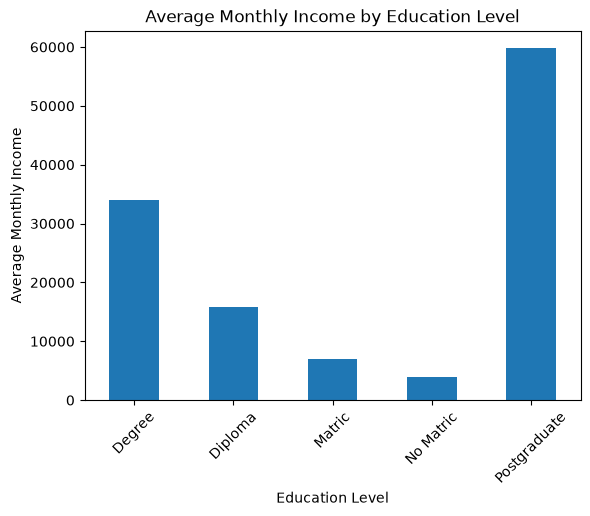

In [26]:
df.groupby("education_level")["monthly_income"].mean().plot(kind="bar")
plt.title("Average Monthly Income by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Monthly Income")
plt.xticks(rotation=45)

A more comprehensive view of the data is provided by violin plots, which show the distribution of income for each education level, including the median, quartiles, and density of the data. This allows us to see not only the central tendency but also the variability and potential outliers in income across different education levels.


/var/folders/94/0d9135bx17185spr24txkrmc0000gn/T/ipykernel_48114/1939441633.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x = "education_level", y = "monthly_income", data=df,


Text(0.5, 1.0, 'Monthly Income Distribution by Education Level')

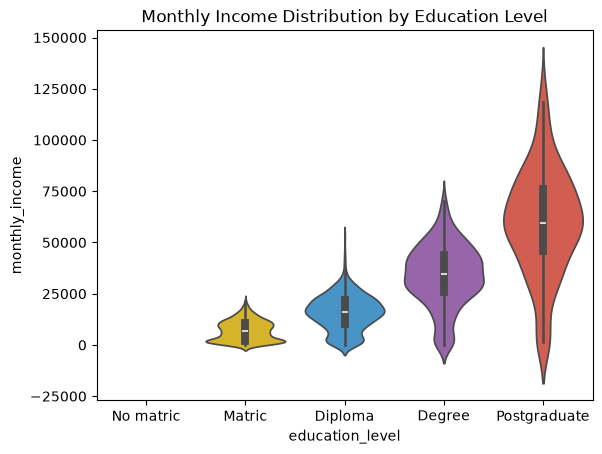

In [27]:
sns.violinplot(x = "education_level", y = "monthly_income", data=df, 
               order=["No matric", "Matric", "Diploma", "Degree", "Postgraduate"],
               palette={"No matric":"#2ecc71", "Matric":"#f1c40f", "Diploma":"#3498db", "Degree":"#9b59b6", "Postgraduate":"#e74c3c"})
plt.title("Monthly Income Distribution by Education Level")

### 2.7.3 Correlation Heatmap / Matrix

The correlation heatmap shows the Pearson correlation coefficient between every pair of the numerical features.

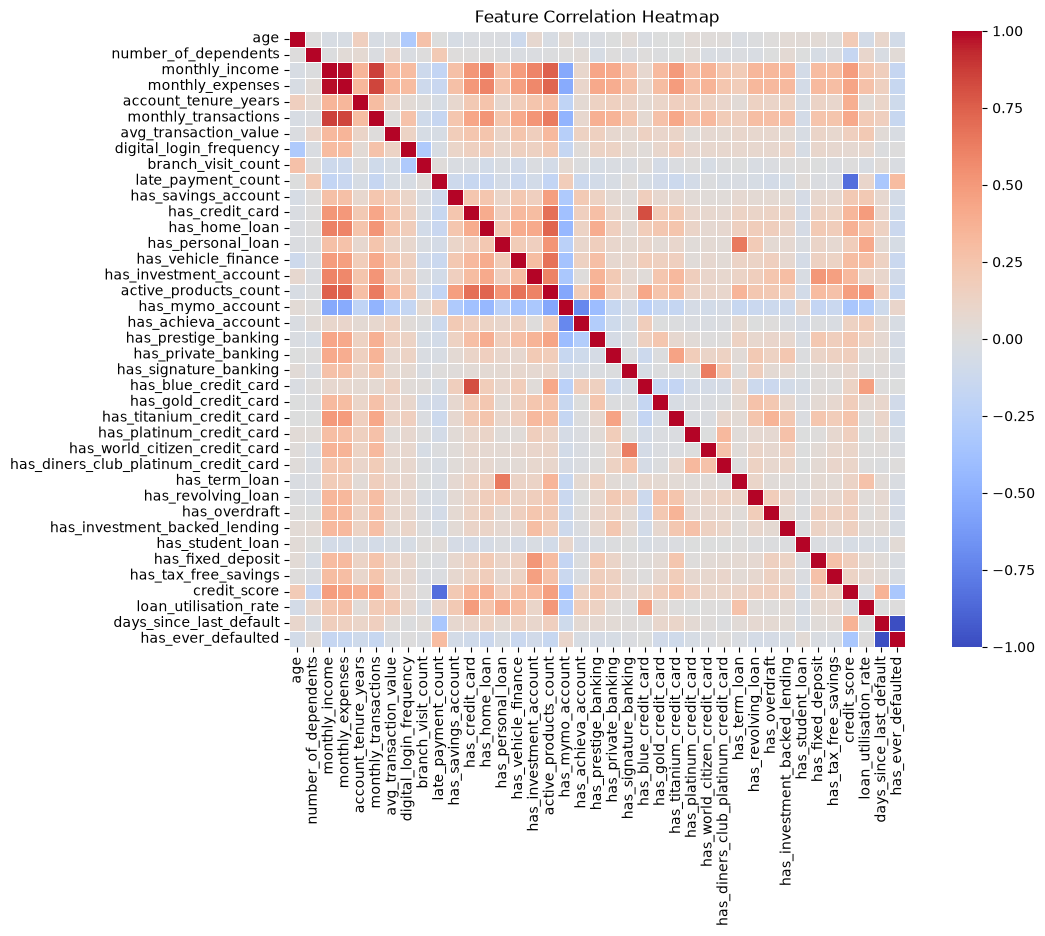

In [28]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm", fmt=".2f", center=0,
            square= True, linewidths=0.5, vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.show()

#### High Correlation between Income and Expenses Handling

The correlation coefficient between monthly income and expenses is extremely high, approximately 0.97. Since these two features are highly correlated, we will engineer a new feature that captures the relationship between these two. This feature will show financial health of the customer and will be more meaningful than income and expenses. This feature will be named savings_rate.

In [29]:
# Create a new feature for savings rate
df['savings_rate'] = (
    (df['monthly_income'] - df['monthly_expenses']) / df['monthly_income']
).replace([np.inf, -np.inf], np.nan).fillna(0)
df['savings_rate'].describe()

count    2000.000000
mean        0.313344
std         0.182628
min        -0.974334
25%         0.249923
50%         0.352226
75%         0.445610
max         1.000000
Name: savings_rate, dtype: float64

#### savings_rate NaN Handling

Rows that have NaN or Infinity values when computing savings_rate due to division edge 
cases are filled with 0, representing customers with no measurable 
savings capacity. No rows are dropped.

### 2.7.4 Credit Score by Churn Risk Category Boxplot

Boxplot showing distribution of credit scores by churn risk label

/var/folders/94/0d9135bx17185spr24txkrmc0000gn/T/ipykernel_48114/1378547307.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="churn_risk_label", y="credit_score", data=df, order=["Low", "Medium", "High"],


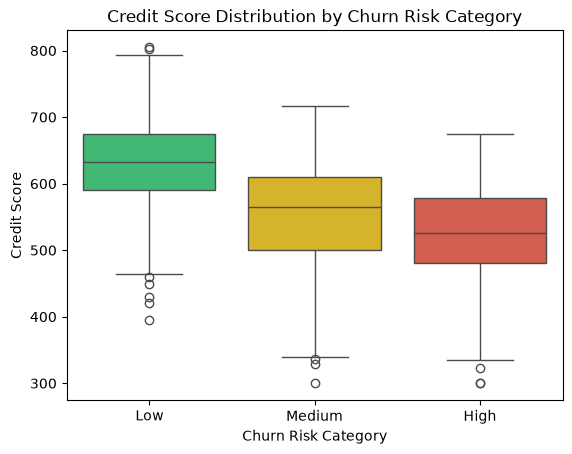

In [30]:
# Churn correlations

sns.boxplot(x="churn_risk_label", y="credit_score", data=df, order=["Low", "Medium", "High"],
            palette={"Low":"#2ecc71", "Medium":"#f1c40f", "High":"#e74c3c"})
plt.title("Credit Score Distribution by Churn Risk Category")
plt.xlabel("Churn Risk Category")
plt.ylabel("Credit Score")
plt.show()

### 2.7.5 Product Ownership by Income Band

Visualize product ownership for each income band. We won't include savings account as every customer has one.

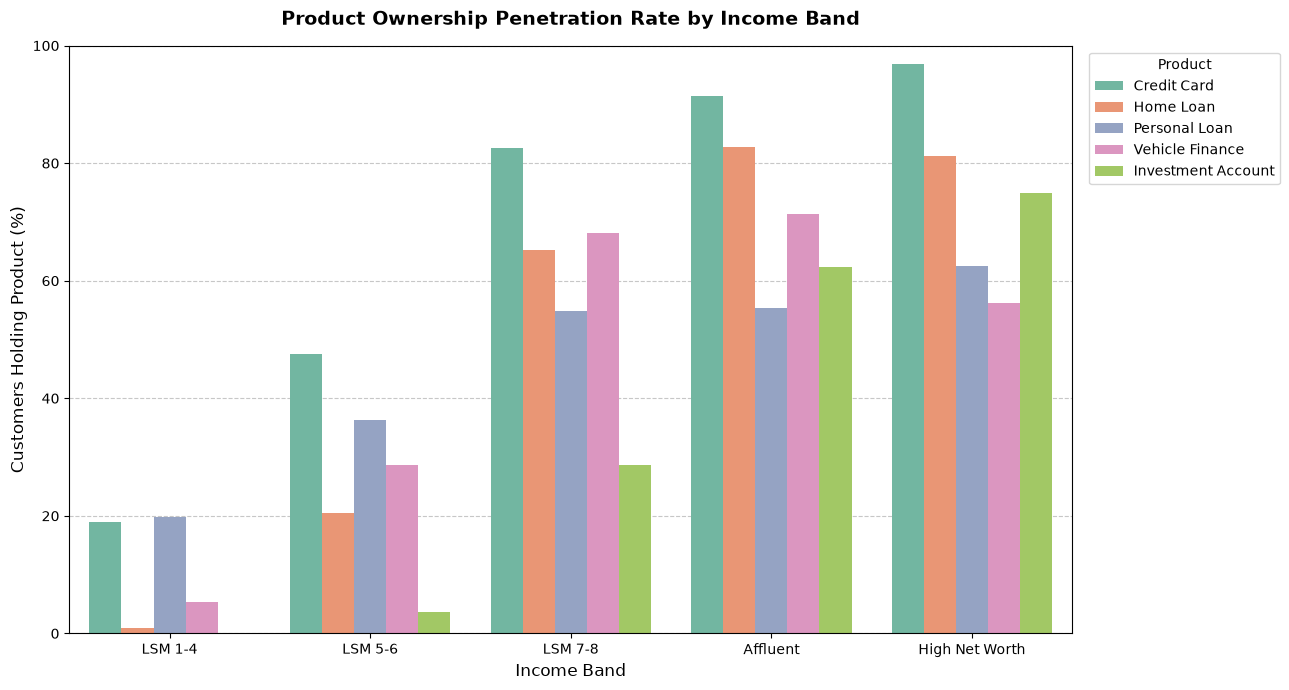

In [31]:
product_cols = [
    'has_credit_card', 'has_home_loan', 'has_personal_loan',
    'has_vehicle_finance', 'has_investment_account'
]

income_order = ["LSM 1-4", "LSM 5-6", "LSM 7-8", "Affluent", "High Net Worth"]

# Calculate penetration rate (% of customers in each band who hold each product)
penetration = (
    df.groupby('income_band')[product_cols]
    .mean()                         
    .mul(100)                        
    .reindex(income_order)          
    .reset_index()
)

# Reshape from wide to long format — seaborn needs this for grouped bar charts
penetration_long = penetration.melt(
    id_vars='income_band',
    var_name='product',
    value_name='penetration_rate'
)

penetration_long['product'] = penetration_long['product'].str.replace('has_', '').str.replace('_', ' ').str.title()

fig, ax = plt.subplots(figsize=(13, 7))

sns.barplot(
    data=penetration_long,
    x='income_band',
    y='penetration_rate',
    hue='product',
    order=income_order,
    palette='Set2',
    ax=ax
)

ax.set_title("Product Ownership Penetration Rate by Income Band",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Income Band", fontsize=12)
ax.set_ylabel("Customers Holding Product (%)", fontsize=12)
ax.legend(title="Product", bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(0, 100)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 2.7.6 Customer Behavioral Profiles Across Churn Risk Category

Visualize customer behaviour profiles across churn risk categories by looking at engagement metrics like digital login frequency, monthly transactions, and active products count. We should see that high churn risk customers have lower engagement levels compared to low churn risk customers.  

/var/folders/94/0d9135bx17185spr24txkrmc0000gn/T/ipykernel_48114/2521517367.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')


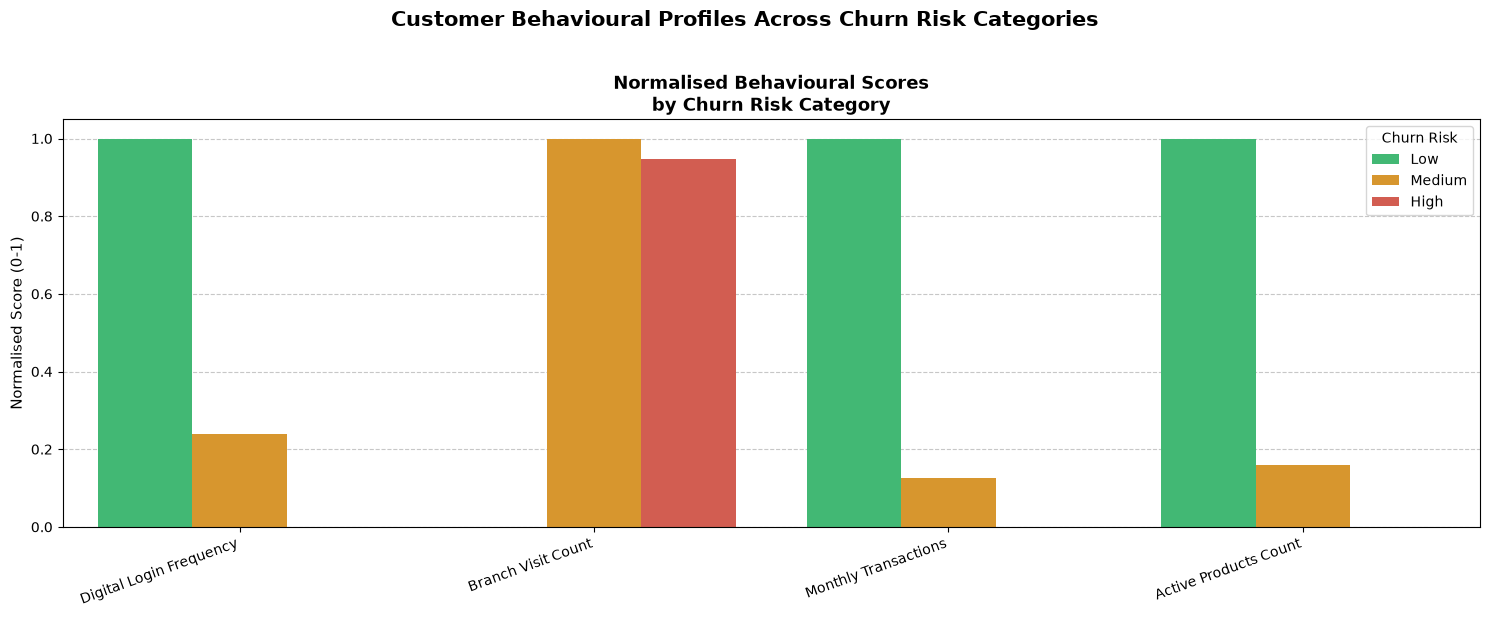

In [32]:
behavioural_cols = [
    'digital_login_frequency',
    'branch_visit_count',
    'monthly_transactions',
    'active_products_count'
]

churn_order  = ["Low", "Medium", "High"]
churn_colors = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}

behavioural_profile = (
    df.groupby('churn_risk_label')[behavioural_cols]
    .mean()
    .reindex(churn_order)
)

# Normalise (min-max) each column to 0-1 scale so they're comparable on one chart
#
behavioural_normalised = (behavioural_profile - behavioural_profile.min()) / (
    behavioural_profile.max() - behavioural_profile.min()
)

# Reshape to long format for seaborn
behavioural_long = (
    behavioural_normalised
    .reset_index()
    .melt(id_vars='churn_risk_label', var_name='metric', value_name='normalised_score')
)


behavioural_long['metric'] = (
    behavioural_long['metric']
    .str.replace('_', ' ')
    .str.title()
)

fig, ax = plt.subplots(figsize=(15, 6))


sns.barplot(
    data=behavioural_long,
    x='metric',
    y='normalised_score',
    hue='churn_risk_label',
    hue_order=churn_order,
    palette=churn_colors,
    ax=ax
)
ax.set_title("Normalised Behavioural Scores\nby Churn Risk Category",
                  fontsize=13, fontweight='bold')
ax.set_xlabel("")
ax.set_ylabel("Normalised Score (0-1)", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(title="Churn Risk")
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)


plt.suptitle("Customer Behavioural Profiles Across Churn Risk Categories",
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

### 2.7.7 Credit Score vs Monthly Income by Churn Risk Label

Scatter plot to see relationship between income and credit score, colored by churn risk label. We should see that higher income customers tend to have higher credit scores, and that low churn risk customers are clustered in the high income, high credit score area, while high churn risk customers are more spread out with lower incomes and credit scores.


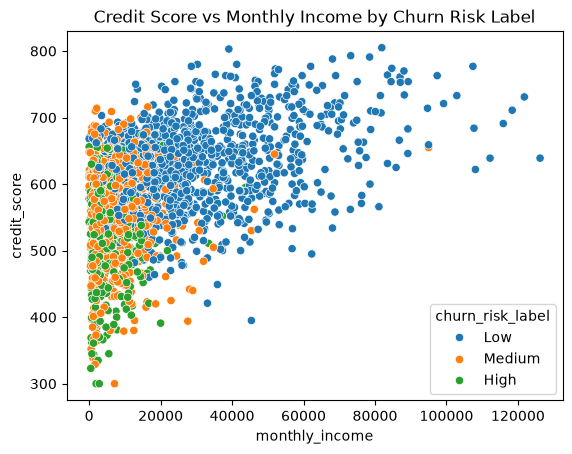

In [33]:
sns.scatterplot(
    x="monthly_income",
    y="credit_score",
    hue="churn_risk_label",
    data=df
)
plt.title("Credit Score vs Monthly Income by Churn Risk Label")
plt.show()


### 2.7.8 Churn Risk Category by Loan Utilization Rate Boxplot

Visualize churn risk by loan utilisation rate. We should see a strong correlation where higher loan utilisation rates correspond to lower churn risk categories.

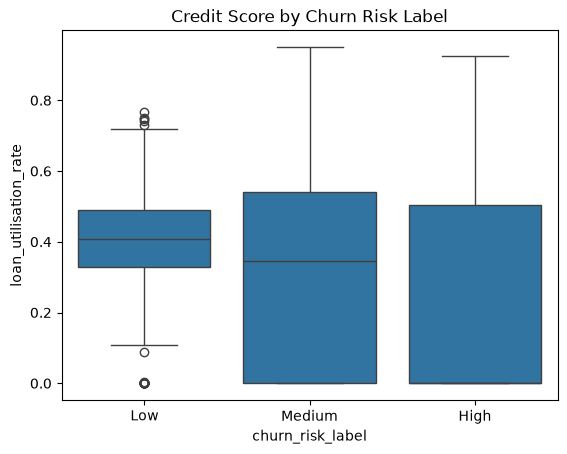

In [34]:
sns.boxplot(x="churn_risk_label", y="loan_utilisation_rate", data=df, order=["Low", "Medium", "High"])
plt.title("Credit Score by Churn Risk Label")
plt.show()

# 3. Customer Segmentation (Clustering)

In this section, we apply machine learning techniques to segment customers based on their profiles.

In [36]:
# import the libraries for clustering

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

### 3.1 Feature Selection

Some of the columns in the data can be excluded for clustering as they are either identifiers, target variables, or not relevant for clustering. These include:
- 'customer_id': This is a unique identifier for each customer and does not contain meaningful information for clustering.
- 'churn_risk_label': This is the target variable we want to predict, so it should not be included in the clustering process.

In [37]:
# Exclude non-feature columns and target variable from clustering
exclude_cols = ['customer_id', 'first_name', 'last_name',
                'churn_risk_label', 'income_band', 
                'preferred_channel']


Some of the categorical columns are relevant for clustering, and they will be encoded, using one-hote encode.

In [38]:
# Define columns to encode
categorical_to_encode = ['gender', 'marital_status', 
                         'education_level', 'employment_status', 'province']

# Create dummy variables for categorical features
df_encoded = pd.get_dummies(df, columns=categorical_to_encode, drop_first=True)
# drop_fist=True Removes one dummy column per feature to avoid multicollinearity

In [39]:
# Select features for clustering (exclude identifiers and target variable)
clustering_features = [col for col in df_encoded.columns if col not in exclude_cols]
X = df_encoded[clustering_features]



### 3.2 Scale with RobustScaler



##### Different Scaling Methods

1. StandardScaler
- This works well for normally (Gaussian) distributed data but is sensitive to outliers, which we have in our dataset. Transforms each feature to have mean = 0 and std = 1.

2. MinMaxScaler
- This doesn't work well with outliers. It scales each feature to a fixed range using:  scaled = (value-min)/(max-min).

3. Normalizer
- This will scale each customers instead of each feature so that each customer vector has unit lenth.

3. RobustScaler 
- Uses the median and IQR, making it more robust to outliers and a better choice for our clustering features, as we have a lot of outliers, such as high incomers for monthly income. With RobustScaler, the extreme values do not distort the scaling of other values. 
- scaled = (value-median)/ IQR

In [40]:
# Scale the features using RobustScaler to handle outliers
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

### 3.3 Finding the Optimal Number of Clusters

In this section, we use the Elbow and Silhouette methods to find the optimal number of clusters.

#### 3.3.1. Elbow Method

In the Elbow method, we find the number of k clusters where inertia stops dropping rapidly.

In [41]:
inertia_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10, max_iter=300)
    # 'kmeans++' initialization helps to improve convergence and cluster quality
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
    print(f"K={k} | Inertia: {kmeans.inertia_:.2f}")



K=2 | Inertia: 22373.74
K=3 | Inertia: 20388.77
K=4 | Inertia: 19236.65
K=5 | Inertia: 18537.68
K=6 | Inertia: 17943.02
K=7 | Inertia: 17456.91
K=8 | Inertia: 17014.64
K=9 | Inertia: 16680.92
K=10 | Inertia: 16412.55


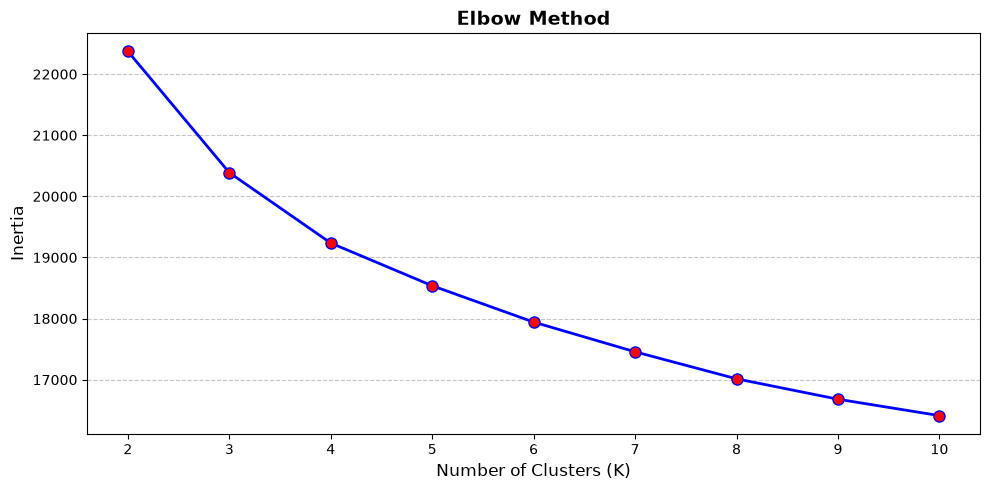

In [42]:
# Plot the inertial values to visualize the elbow method for optimal K selection
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(k_range, inertia_values, 'bo-', linewidth=2, markersize=8, markerfacecolor='red')
ax.set_xlabel("Number of Clusters (K)", fontsize=12)
ax.set_ylabel("Inertia", fontsize=12)
ax.set_title("Elbow Method", fontsize=14, fontweight='bold')
ax.set_xticks(list(k_range))
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

#### 2. Silhouette Score

The Silhouette method measures how well a data point fits in the placed cluster. It computes the average distance between the data point and all other data points in the cluster, as well as the average distance between the data point and all other data points in the nearest other cluster. A higher score (-1 to 1) means the data point is well placed in its cluster. 

In [43]:
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels, sample_size=500,random_state=42)
    silhouette_scores.append(score)
    print(f"K={k} | Silhouette Score: {score:.4f}")

K=2 | Silhouette Score: 0.1604
K=3 | Silhouette Score: 0.1181
K=4 | Silhouette Score: 0.0977
K=5 | Silhouette Score: 0.0935
K=6 | Silhouette Score: 0.0922
K=7 | Silhouette Score: 0.0894
K=8 | Silhouette Score: 0.0812
K=9 | Silhouette Score: 0.0744
K=10 | Silhouette Score: 0.0688


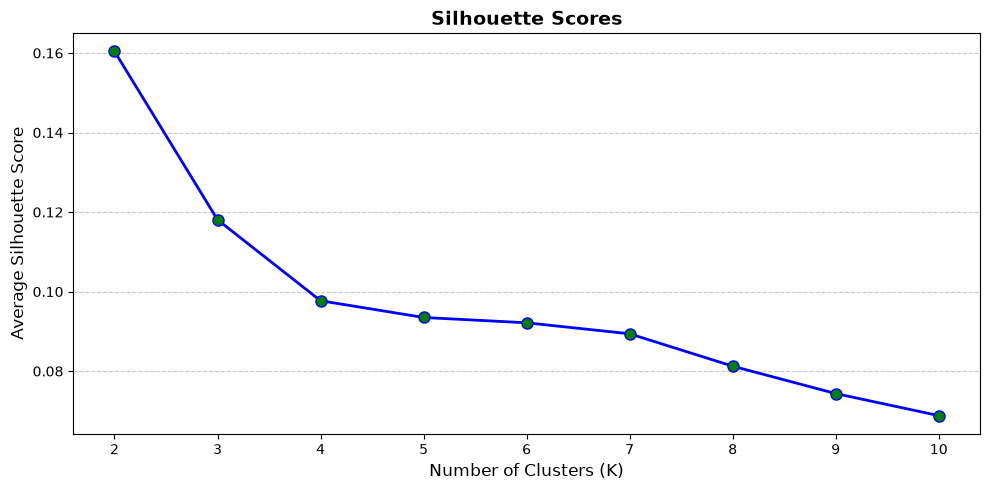

In [44]:
# Plot the silhouette scores to visualize the optimal K selection
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8, markerfacecolor='green')
ax.set_xlabel("Number of Clusters (K)", fontsize=12)
ax.set_ylabel("Average Silhouette Score", fontsize=12)
ax.set_title("Silhouette Scores", fontsize=14, fontweight='bold')
ax.set_xticks(list(k_range))
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()

plt.show()

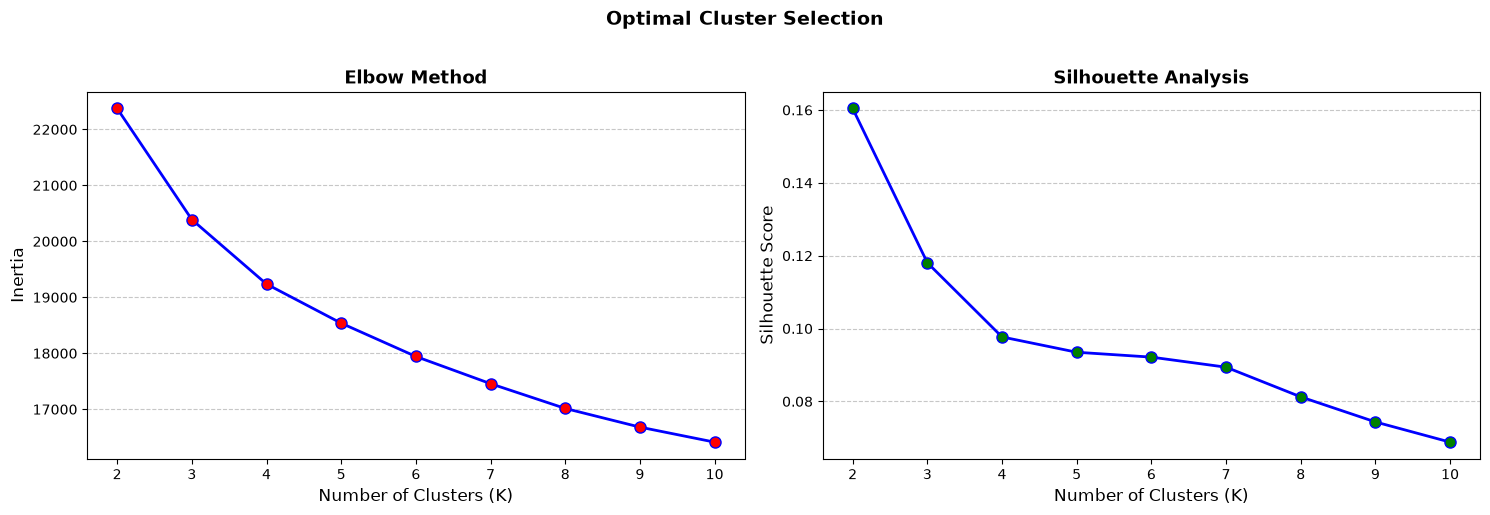

In [45]:
# Plot the two methods side by side for easy comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow
axes[0].plot(k_range, inertia_values, 'bo-', linewidth=2, 
             markersize=8, markerfacecolor='red')
axes[0].set_xlabel("Number of Clusters (K)", fontsize=12)
axes[0].set_ylabel("Inertia", fontsize=12)
axes[0].set_title("Elbow Method", fontsize=13, fontweight='bold')
axes[0].set_xticks(list(k_range))
axes[0].yaxis.grid(True, linestyle='--', alpha=0.7)
axes[0].set_axisbelow(True)

# Silhouette
axes[1].plot(k_range, silhouette_scores, 'bo-', linewidth=2,
             markersize=8, markerfacecolor='green')
axes[1].set_xlabel("Number of Clusters (K)", fontsize=12)
axes[1].set_ylabel("Silhouette Score", fontsize=12)
axes[1].set_title("Silhouette Analysis", fontsize=13, fontweight='bold')
axes[1].set_xticks(list(k_range))
axes[1].yaxis.grid(True, linestyle='--', alpha=0.7)
axes[1].set_axisbelow(True)

plt.suptitle("Optimal Cluster Selection",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### Interpreting the Results

The elbow method indicates that there is a sharp curve around K = 3 and K = 4. This could be our optimal number of clusters. However, we have to check the Silhouette scores and confirm if the two methods are in agreement. From the scores, the highest score is 0.16 for K = 2. This is considered very weak, reflecting that there is no structure found in the data. This could be due to the high dimensionality of the data. We have 42 features. It could also be a result of the one-hot encoded features.

To deal with this, we will try Principal Component Analysis (PCA) first. This basically projects the data into smaller number of dimensions and capture the most important and relevant information.

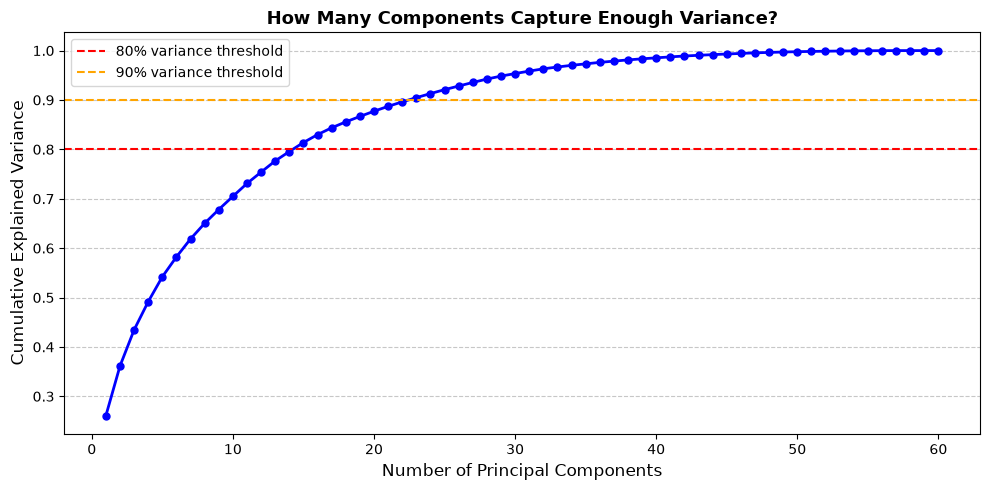

80% variance captured by 15 components
85% variance captured by 18 components
90% variance captured by 23 components


In [46]:
# PCA

from sklearn.decomposition import PCA

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

# Plot cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
        'bo-', linewidth=2, markersize=5)
ax.axhline(y=0.80, color='red',    linestyle='--', label='80% variance threshold')
ax.axhline(y=0.90, color='orange', linestyle='--', label='90% variance threshold')
ax.set_xlabel("Number of Principal Components", fontsize=12)
ax.set_ylabel("Cumulative Explained Variance", fontsize=12)
ax.set_title("How Many Components Capture Enough Variance?", 
             fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


for threshold in [0.80, 0.85, 0.90]:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    print(f"{threshold*100:.0f}% variance captured by {n_components} components")

In [47]:
# Apply PCA with chosen components
N_COMPONENTS = 15 

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance retained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Variance retained: 81.4%


Initial clustering on 42 features produced low silhouette scores , likely due to the high-dimensionality.

PCA was applied to reduce the feature space while retaining meaningful variance:
- Original dimensions: 42
- Retained dimensions: 15  
- Variance retained: ~85%

This reduction removes dimensional noise while 
preserving the dominant financial, behavioural and risk signals. 

We repeat the elbow and silhouette analysis on the PCA-transformed data.

K= 2 | Inertia:   17333.00 | Silhouette: 0.1858
K= 3 | Inertia:   15357.22 | Silhouette: 0.1462
K= 4 | Inertia:   14208.67 | Silhouette: 0.1250
K= 5 | Inertia:   13520.39 | Silhouette: 0.1242
K= 6 | Inertia:   12965.42 | Silhouette: 0.1187
K= 7 | Inertia:   12483.38 | Silhouette: 0.1200
K= 8 | Inertia:   12087.04 | Silhouette: 0.1039
K= 9 | Inertia:   11753.12 | Silhouette: 0.0978
K=10 | Inertia:   11510.30 | Silhouette: 0.0960
K=11 | Inertia:   11250.86 | Silhouette: 0.0902


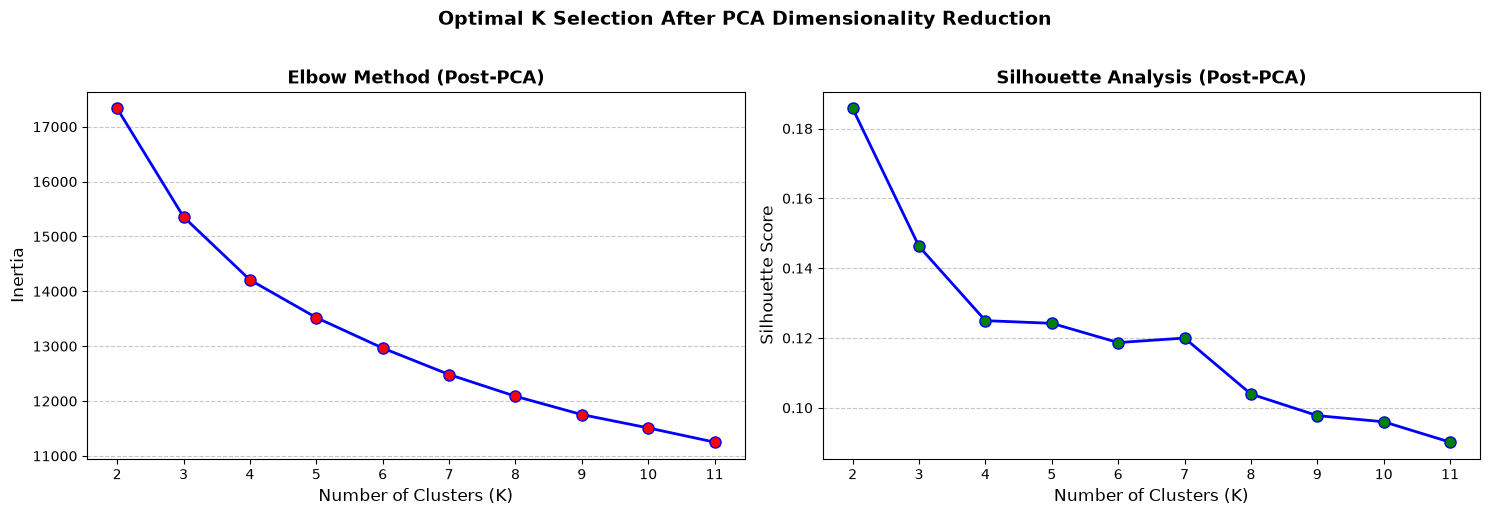

In [48]:

inertia_pca     = []
silhouette_pca  = []
k_range         = range(2, 12)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42,
        max_iter=300
    )
    labels = kmeans.fit_predict(X_pca)
    inertia_pca.append(kmeans.inertia_)
    score = silhouette_score(X_pca, labels, sample_size=500, random_state=42)
    silhouette_pca.append(score)
    print(f"K={k:2d} | Inertia: {kmeans.inertia_:>10.2f} | Silhouette: {score:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(k_range, inertia_pca, 'bo-', linewidth=2,
             markersize=8, markerfacecolor='red')
axes[0].set_xlabel("Number of Clusters (K)", fontsize=12)
axes[0].set_ylabel("Inertia", fontsize=12)
axes[0].set_title("Elbow Method (Post-PCA)", fontsize=13, fontweight='bold')
axes[0].set_xticks(list(k_range))
axes[0].yaxis.grid(True, linestyle='--', alpha=0.7)
axes[0].set_axisbelow(True)

axes[1].plot(k_range, silhouette_pca, 'bo-', linewidth=2,
             markersize=8, markerfacecolor='green')
axes[1].set_xlabel("Number of Clusters (K)", fontsize=12)
axes[1].set_ylabel("Silhouette Score", fontsize=12)
axes[1].set_title("Silhouette Analysis (Post-PCA)", fontsize=13, fontweight='bold')
axes[1].set_xticks(list(k_range))
axes[1].yaxis.grid(True, linestyle='--', alpha=0.7)
axes[1].set_axisbelow(True)

plt.suptitle("Optimal K Selection After PCA Dimensionality Reduction",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### Interpreting the Results

Both the Elbow method and Silhouette method were applied across K=2 to K=11 with the original 42 features, and again after PCA dimensionality reduction with 15 features. The goal was to get a silhouette score of at least 0.25, as this is generally considered good enough to have structure in the data. With PCA dimensionality reduction, the silhouette scores marginally increased but remained well below 0.25, indicating overlapping customer clusters.

##### Choosing the optimal K

From the Elbow method, the elbow point appears around 𝐾=3 or 𝐾=4. In contrast, the Silhouette method suggests that the optimal number of clusters is 𝐾=2, as this yields the highest silhouette score. Since these two methods do not agree, we must select 𝐾 based on practical business considerations.

- 𝐾=2: Produces only two clusters, essentially dividing customers into broad categories such as “financially healthy” and “financially unhealthy.” This oversimplification is not particularly useful for nuanced customer segmentation.

- 𝐾=3: Provides three clusters, which is an improvement, but still limits the granularity of insights.

- 𝐾=4: Offers four distinct clusters, enabling the recommendation engine to generate more differentiated and targeted suggestions. This level of segmentation is more valuable for business applications. 

We select 𝐾=4 as the optimal number of clusters, balancing statistical methods with business practicality to achieve meaningful customer segmentation.



#### 3.3.3 Fitting the Final Model


In [49]:
# Final KMeans with optimal K on PCA-reduced data
OPTIMAL_K = 4

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, 
                      init='k-means++', n_init=10, max_iter=300)
final_labels = kmeans_final.fit_predict(X_pca)
df['cluster'] = final_labels

In [50]:
# Analyze cluster characteristics
cluster_counts = df['cluster'].value_counts().sort_index()
print("Cluster Counts:")
print(cluster_counts)
print(f"\nSmallest cluster has {cluster_counts.min()} customers, largest has {cluster_counts.max()} customers")

Cluster Counts:
cluster
0    636
1    271
2    682
3    411
Name: count, dtype: int64

Smallest cluster has 271 customers, largest has 682 customers


We have 4 distinct clusters, with a satisfying distribution of customers in each cluster.


### 3.4 Cluster Profiling

We have 4 distinct clusters of customers, but they are meaningless because they are not profiled. As of now, its just cluster 1,2,3,4. Now we can profile each cluster so that each cluster has customers who share the same characteristics. 

In [51]:
# Profile clusters based on key features. Use original data, unscaled and with categorical features in their original form for interpretability.

profile_features = [
    # Financial features
    'monthly_income', 'savings_rate', 'account_tenure_years',
    # Risk features
    'credit_score', 'loan_utilisation_rate', 'late_payment_count',
    'has_ever_defaulted',
    # Behavioural features
    'digital_login_frequency', 'branch_visit_count',
    'monthly_transactions', 'avg_transaction_value',
    # Product features
    'active_products_count', 'has_credit_card', 'has_home_loan',
    'has_personal_loan', 'has_vehicle_finance', 'has_investment_account',
    # Target feature
    'churn_risk_label'
] 

# Mean of numerical features per cluster
cluster_profile = df.groupby('cluster')[profile_features[:-1]].mean().round(3)


In [52]:
# Cluster Profile
cluster_profile

,monthly_income,savings_rate,account_tenure_years,credit_score,loan_utilisation_rate,late_payment_count,has_ever_defaulted,digital_login_frequency,branch_visit_count,monthly_transactions,avg_transaction_value,active_products_count,has_credit_card,has_home_loan,has_personal_loan,has_vehicle_finance,has_investment_account
cluster,,,,,,,,,,,,,,,,,
0,7297.846,0.377,5.109,594.580,0.216,1.362,0.560,12.285,3.810,15.085,371.261,1.448,0.195,0.057,0.245,0.112,0.013
1,58459.041,0.402,8.439,669.642,0.375,1.369,0.399,18.413,3.030,49.140,729.760,4.716,0.919,0.867,0.561,0.694,0.675
2,23349.377,0.380,6.212,605.934,0.448,1.811,0.589,14.809,3.468,25.575,642.194,3.569,0.817,0.506,0.497,0.579,0.185
3,4030.733,0.046,5.001,491.891,0.272,4.017,0.808,12.263,3.774,12.937,380.981,1.214,0.195,0.015,0.217,0.056,0.000


In [53]:
# Find the most common churn risk label per cluster
cluster_profile['dominant_churn_risk'] = (
    df.groupby('cluster')['churn_risk_label']
    .agg(lambda x: x.value_counts().index[0])
)

# cluster size
cluster_profile['cluster_size'] = df['cluster'].value_counts().sort_index()

print(cluster_profile.T)  # Transpose for better readability

cluster                         0          1          2         3
monthly_income           7297.846  58459.041  23349.377  4030.733
savings_rate                0.377      0.402       0.38     0.046
account_tenure_years        5.109      8.439      6.212     5.001
credit_score               594.58    669.642    605.934   491.891
loan_utilisation_rate       0.216      0.375      0.448     0.272
late_payment_count          1.362      1.369      1.811     4.017
has_ever_defaulted           0.56      0.399      0.589     0.808
digital_login_frequency    12.285     18.413     14.809    12.263
branch_visit_count           3.81       3.03      3.468     3.774
monthly_transactions       15.085      49.14     25.575    12.937
avg_transaction_value     371.261     729.76    642.194   380.981
active_products_count       1.448      4.716      3.569     1.214
has_credit_card             0.195      0.919      0.817     0.195
has_home_loan               0.057      0.867      0.506     0.015
has_person

##### Visualize the Profiles of the Clusters

Now we want to visualize the characteristics of the clusters to get a better look at how each cluster is defined.

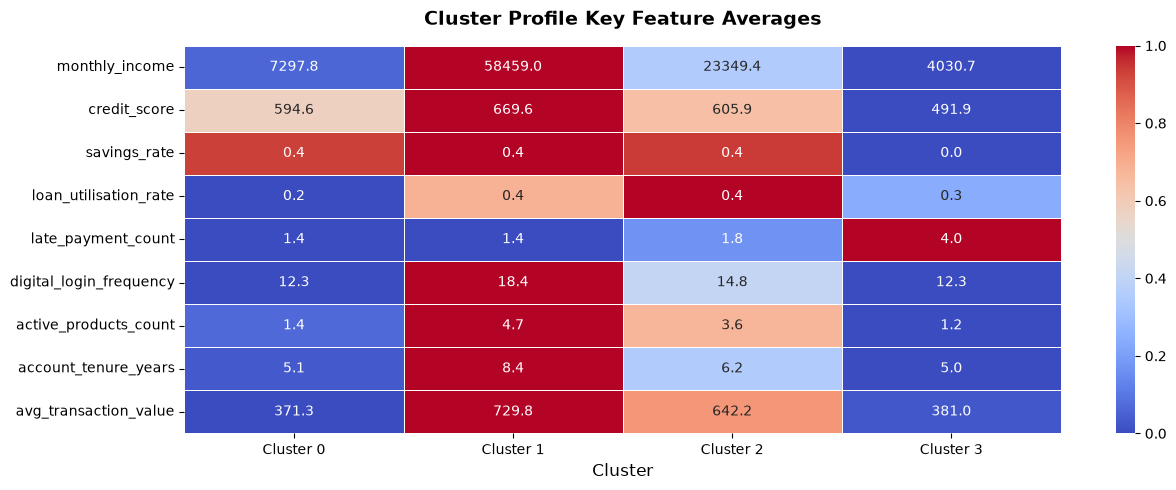

In [54]:
heatmap_features = [
    'monthly_income', 'credit_score', 'savings_rate',
    'loan_utilisation_rate', 'late_payment_count',
    'digital_login_frequency', 'active_products_count',
    'account_tenure_years', 'avg_transaction_value'
]

# Normalise profile values to 0-1 for visualization
profile_heatmap = cluster_profile[heatmap_features].copy()
profile_normalised = (profile_heatmap - profile_heatmap.min()) / (
    profile_heatmap.max() - profile_heatmap.min()
)

fig, ax = plt.subplots(figsize=(13, 5))

sns.heatmap(
    profile_normalised.T,       # Transpose 
    annot=cluster_profile[heatmap_features].T,  # Show actual values not normalised
    fmt=".1f",
    cmap="coolwarm",
    linewidths=0.5,
    ax=ax
)

ax.set_title("Cluster Profile Key Feature Averages",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Cluster", fontsize=12)
ax.set_ylabel("")
ax.set_xticklabels([f"Cluster {i}" for i in range(OPTIMAL_K)], rotation=0)

plt.tight_layout()
plt.show()

##### Visualize Cluster Distribution

Visualize the cluster distribution for key features using histograms to understand the spread and central tendencies of each feature within clusters.

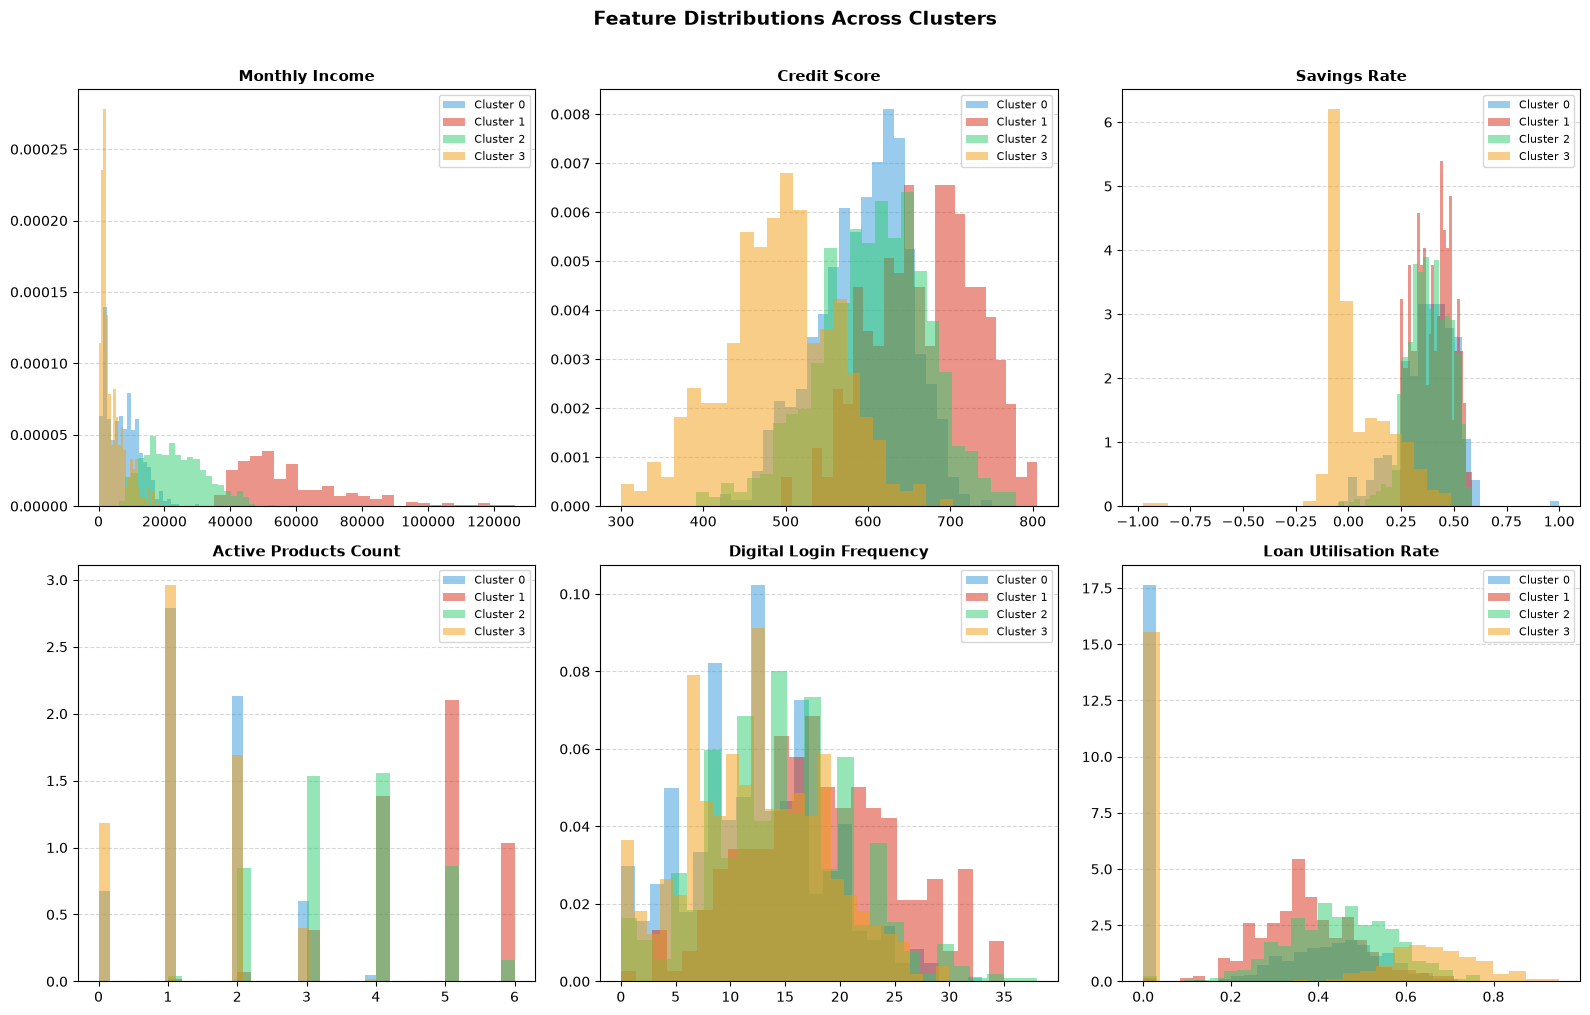

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

distribution_features = [
    'monthly_income', 'credit_score', 'savings_rate',
    'active_products_count', 'digital_login_frequency', 'loan_utilisation_rate'
]

cluster_palette = {0: "#3498db", 1: "#d82a17", 2: "#2ecc71", 3: "#f39c12"}

for idx, feature in enumerate(distribution_features):
    for cluster_id in range(OPTIMAL_K):
        cluster_data = df[df['cluster'] == cluster_id][feature]
        axes[idx].hist(
            cluster_data,
            bins=25,
            alpha=0.5,
            label=f"Cluster {cluster_id}",
            color=cluster_palette[cluster_id],
            density=True        # Normalise so clusters of different sizes are comparable
        )
    axes[idx].set_title(feature.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("")
    axes[idx].legend(fontsize=8)
    axes[idx].yaxis.grid(True, linestyle='--', alpha=0.5)
    axes[idx].set_axisbelow(True)

plt.suptitle("Feature Distributions Across Clusters",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The cluster distributions show the overlapping nature of the clusters, however, we can still see some differences in the shapes and peaks of the distributions which indicate that the clusters do have distinct characteristics, even if they are not perfectly separated.

##### Visualize In 2D using PCA Components

The clusters exist in a 42-dimensional space. As noted earlier, the separation between clusters is not perfect and is difficult to visualize directly. To address this, we project the clusters onto the first two principal components derived from PCA (Principal Component Analysis). This allows us to create a scatter plot that clearly show the clusters and their relative separations.

In addition to the first two components, we can also plot other pairs of principal components to further study the separations and gain deeper insights into the structure of the data. 

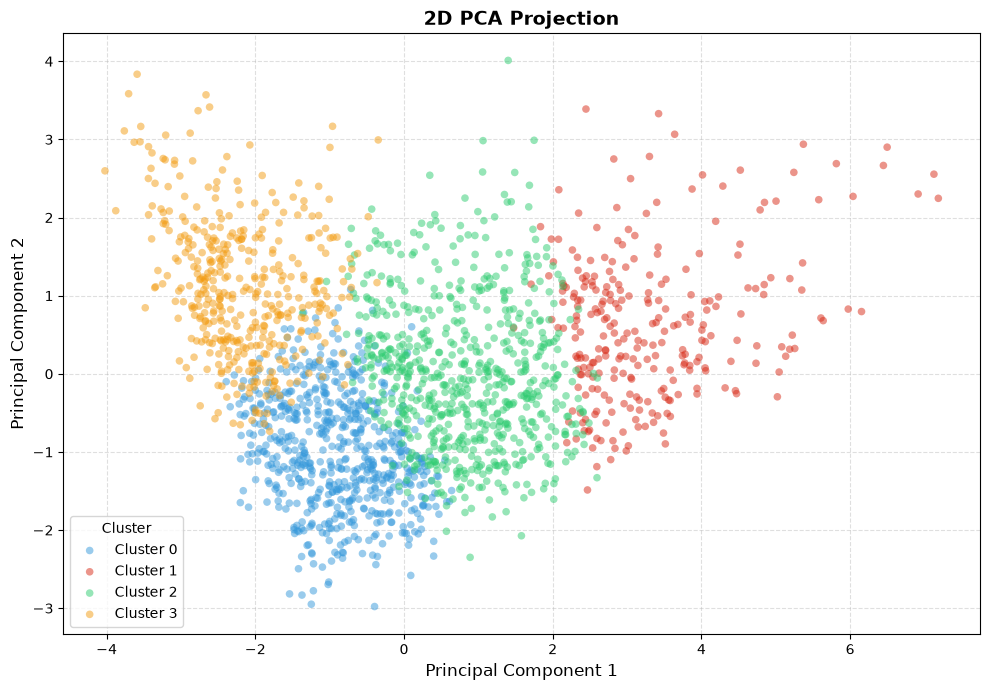

In [56]:
fig, ax = plt.subplots(figsize=(10, 7))

for cluster_id in range(OPTIMAL_K):
    mask = df['cluster'] == cluster_id
    ax.scatter(
        X_pca[mask, 0],         # First principal component
        X_pca[mask, 1],         # Second principal component
        c=cluster_palette[cluster_id],
        label=f"Cluster {cluster_id}",
        alpha=0.5,
        s=30,
        edgecolors='none'
    )

ax.set_xlabel("Principal Component 1", fontsize=12)
ax.set_ylabel("Principal Component 2", fontsize=12)
ax.set_title("2D PCA Projection",
             fontsize=14, fontweight='bold')
ax.legend(title="Cluster", fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

##### Naming the Clusters Based on Cluster Characteristics

Four distinct customer segments were identified through KMeans clustering 
on PCA-reduced features.

**Cluster 0 — Stable Middles:** Middle-income, stable financial 
behaviour, moderate product engagement. Core retail banking segment.

**Cluster 1 — Premium Loyalists:** Highest income, credit score, 
product depth and tenure. The bank's most valuable segment.

**Cluster 2 — Financially Vulnerable:** Lowest income and credit 
score, zero savings, highest late payment count. Requires financial 
wellness intervention.

**Cluster 3 — Emerging Potentials:** Low income but financially 
disciplined, good savings rate and low loan utilisation. Underserved 
growth opportunity.



In [57]:
cluster_names = {
    0: "Stable Middles",
    1: "Premium Loyalists",
    2: "Financially Vulnerable",
    3: "Emerging Potentials"
}

df['cluster_name'] = df['cluster'].map(cluster_names)
print(df['cluster_name'].value_counts())

cluster_name
Financially Vulnerable    682
Stable Middles            636
Emerging Potentials       411
Premium Loyalists         271
Name: count, dtype: int64


# 4. Recommendation Engine

In this section, we develop a product recommendation engine. The engine is designed to be needs-based, meaning that recommendations are tailored to each customer’s specific financial profile and requirements. By leveraging customer segmentation and behavioral data, the system can suggest relevant products that align with individual needs, rather than offering generic recommendations.

### 4.1 Define the Bank's Product Catalogue

Each product has:
- description
- min_income: minimum monthly income required
- min_credit_score: minimum credit score required  
- target_segments: which cluster names this product suits
- existing_column: the column in df that tracks current ownership (None if new)

In [58]:
product_catalogue = {
    "MyMo Account": {
        "description": "A low-cost everyday bank account for routine banking, card payments, digital banking and money transfers.",
        "target_segments": ["Financially Vulnerable", "Emerging Potentials"],
        "min_income": 0,
        "min_credit_score": 0,
        "existing_column": "has_mymo_account",
    },
    "Achieva Account": {
        "description": "An everyday transactional account for customers earning a regular income, with access to digital banking and day-to-day payment services.",
        "target_segments": ["Emerging Potentials", "Stable Middles"],
        "min_income": 8000,
        "min_credit_score": 550,
        "existing_column": "has_achieva_account",
    },
    "Prestige Banking": {
        "description": "A premium personal banking tier offering enhanced service, benefits and relationship support for established earners.",
        "target_segments": ["Stable Middles", "Premium Loyalists"],
        "min_income": 25000,
        "min_credit_score": 620,
        "existing_column": "has_prestige_banking",
    },
    "Private Banking": {
        "description": "A high-value banking service combining tailored relationship management, specialist advice, wealth planning and premium benefits.",
        "target_segments": ["Premium Loyalists"],
        "min_income": 58000,
        "min_credit_score": 680,
        "existing_column": "has_private_banking",
    },
    "Signature Banking": {
        "description": "An upper-tier banking proposition for very high-income customers, with premium relationship service and specialised banking benefits.",
        "target_segments": ["Premium Loyalists"],
        "min_income": 92000,
        "min_credit_score": 680,
        "existing_column": "has_signature_banking",
    },
    "Gold Credit Card": {
        "description": "A mainstream credit card offering everyday revolving credit and card benefits, subject to affordability and credit assessment.",
        "target_segments": ["Emerging Potentials", "Stable Middles"],
        "min_income": 5000,
        "min_credit_score": 580,
        "existing_column": "has_gold_credit_card",
    },
    "Titanium Credit Card": {
        "description": "A higher-tier credit card for customers seeking increased credit access and additional card benefits.",
        "target_segments": ["Emerging Potentials", "Stable Middles"],
        "min_income": 25000,
        "min_credit_score": 600,
        "existing_column": "has_titanium_credit_card",
    },
    "Platinum Credit Card": {
        "description": "A premium credit card with enhanced benefits and services for customers meeting the relevant income and credit criteria.",
        "target_segments": ["Premium Loyalists", "Stable Middles"],
        "min_income": 58000,
        "min_credit_score": 650,
        "existing_column": "has_platinum_credit_card",
    },
    "Blue Credit Card": {
        "description": "An entry-level credit card for everyday purchases, with a revolving credit facility subject to affordability and credit assessment.",
        "target_segments": ["Financially Vulnerable", "Emerging Potentials", "Stable Middles"],
        "min_income": 5000,
        "min_credit_score": 550,
        "existing_column": "has_blue_credit_card",
    },
    "World Citizen Credit Card": {
        "description": "A premium travel-oriented credit card designed for international payments and travel-related benefits.",
        "target_segments": ["Premium Loyalists"],
        "min_income": 92000,
        "min_credit_score": 650,
        "existing_column": "has_world_citizen_credit_card",
    },
    "Diners Club Platinum Credit Card": {
        "description": "A premium Diners Club card offering credit facilities and travel and lifestyle benefits, including applicable airport lounge services.",
        "target_segments": ["Premium Loyalists", "Stable Middles"],
        "min_income": 41000,
        "min_credit_score": 620,
        "existing_column": "has_diners_club_platinum_credit_card",
    },
    "Term Loan": {
        "description": "A fixed-term personal loan repaid through scheduled instalments over an agreed period.",
        "target_segments": ["Emerging Potentials", "Financially Vulnerable"],
        "min_income": 3000,
        "min_credit_score": 500,
        "existing_column": "has_term_loan",
    },
    "Revolving Loan": {
        "description": "A reusable credit facility that allows an approved customer to draw, repay and draw again up to an agreed limit.",
        "target_segments": ["Emerging Potentials", "Stable Middles", "Premium Loyalists"],
        "min_income": 8000,
        "min_credit_score": 580,
        "existing_column": "has_revolving_loan",
    },
    "Overdraft": {
        "description": "A linked transactional-account credit facility that supports short-term cash-flow needs beyond the available balance.",
        "target_segments": ["Emerging Potentials", "Stable Middles", "Premium Loyalists"],
        "min_income": 8000,
        "min_credit_score": 580,
        "existing_column": "has_overdraft",
    },
    "Investment Backed Lending": {
        "description": "A lending facility secured by qualifying investments or assets, providing liquidity without selling the underlying investment.",
        "target_segments": ["Premium Loyalists"],
        "min_income": 50000,
        "min_credit_score": 650,
        "existing_column": "has_investment_backed_lending",
    },
    "Vehicle and Asset Finance": {
        "description": "Finance used to purchase a vehicle or qualifying asset, normally repaid in instalments over an agreed term.",
        "target_segments": ["Stable Middles", "Premium Loyalists"],
        "min_income": 8000,
        "min_credit_score": 600,
        "existing_column": "has_vehicle_finance",
    },
    "Home Loan": {
        "description": "A mortgage facility used to buy, build or refinance residential property over an agreed repayment term.",
        "target_segments": ["Stable Middles", "Premium Loyalists"],
        "min_income": 20000,
        "min_credit_score": 630,
        "existing_column": "has_home_loan",
    },
    "Student Loan": {
        "description": "Education finance intended to cover qualifying study-related costs such as tuition and other approved expenses.",
        "target_segments": ["Emerging Potentials"],
        "min_income": 0,
        "min_credit_score": 0,
        "existing_column": "has_student_loan",
    },
    "Savings Account": {
        "description": "An interest-bearing deposit account for building or holding savings while retaining access to funds under the account rules.",
        "target_segments": ["Financially Vulnerable", "Emerging Potentials", "Stable Middles", "Premium Loyalists"],
        "min_income": 0,
        "min_credit_score": 0,
        "existing_column": "has_savings_account",
    },
    "Fixed Deposit": {
        "description": "A savings or investment account in which money is placed for a fixed term at an agreed interest rate.",
        "target_segments": ["Stable Middles", "Premium Loyalists"],
        "min_income": 10000,
        "min_credit_score": 0,
        "existing_column": "has_fixed_deposit",
    },
    "Tax-Free Savings Account": {
        "description": "A long-term savings or investment account designed to provide tax-free returns within South African contribution limits.",
        "target_segments": ["Stable Middles", "Premium Loyalists"],
        "min_income": 10000,
        "min_credit_score": 0,
        "existing_column": "has_tax_free_savings",
    },
}

### 4.2 Compute Ownership Rate per Cluster

In [59]:
# compute ownership rates for products that exist in the data, by cluster
tracked_products = {
    name: details for name, details in product_catalogue.items()
    if details['existing_column'] is not None
}

# ownership rate table
ownership_rates = {}
for product_name, details in tracked_products.items():
    col = details['existing_column']
    rates = df.groupby('cluster_name')[col].mean().mul(100).round(1)
    ownership_rates[product_name] = rates

ownership_df = pd.DataFrame(ownership_rates)
print("\nProduct Ownership Rates by Cluster (%):")
print(ownership_df.to_string())


Product Ownership Rates by Cluster (%):
                        MyMo Account  Achieva Account  Prestige Banking  Private Banking  Signature Banking  Gold Credit Card  Titanium Credit Card  Platinum Credit Card  Blue Credit Card  World Citizen Credit Card  Diners Club Platinum Credit Card  Term Loan  Revolving Loan  Overdraft  Investment Backed Lending  Vehicle and Asset Finance  Home Loan  Student Loan  Savings Account  Fixed Deposit  Tax-Free Savings Account
cluster_name                                                                                                                                                                                                                                                                                                                                                                                                                           
Emerging Potentials             92.2              7.8               0.0              0.0                0.0    

### 4.3. Recommendation Logic

The recommendation engine applies a three-stage filtering and scoring 
approach designed to balance financial responsibility with business growth.

- Segment Eligibility Filter - Each product in the catalogue defines which customer segments it is 
appropriate for, based on the segment's financial profile and life stage. 


- Financial Eligibility Filter - Each product defines minimum income and credit score thresholds.

- Ownership Gap Scoring - Among eligible products, priority is given to products with the lowest 
current ownership rate in that cluster, the largest untapped opportunity. 

For new products not currently tracked in the dataset, an ownership rate of 0 
is assigned, reflecting maximum opportunity. Products are ranked by gap 
score (gapscore = 1-ownership rate) descending, and the top 3 are selected.


In [60]:
def recommend_products_for_cluster(cluster_name, cluster_profile_row, top_n=3):
    
    """
    Recommends top N products for a given cluster based on:
    - Segment eligibility
    - Financial eligibility
    - Ownership gap
    
    Parameters
    ----------
    cluster_name: str
                - name of the cluster
    cluster_profile_row: Series 
                        - mean feature values for this cluster
    top_n: int   
        — number of products to recommend
    
    Returns
    -------
    List of recommended product names with reasoning
    """
    avg_income       = cluster_profile_row['monthly_income']
    avg_credit_score = cluster_profile_row['credit_score']
    
    recommendations = []
    
    for product_name, details in product_catalogue.items():
        
        # Don't do anything if the product isn't targeted at this segment
        if cluster_name not in details['target_segments']:
            continue
        
        # Don't do anything if the cluster doesn't meet the financial eligibility criteria
        if avg_income < details['min_income']:
            continue

        # Don't do anything if the cluster doesn't meet the credit score eligibility criteria
        if avg_credit_score < details['min_credit_score']:
            continue
        
        # Compute ownership gap score for products that exist in the data. 
        # For new products, we assume maximum gap (1.0) since no one has it yet.
        if details['existing_column'] is not None:
            col = details['existing_column']
            ownership_rate = df[df['cluster_name'] == cluster_name][col].mean()
            gap_score = 1 - ownership_rate 
        else:
            gap_score = 1.0 # Max gap for new products
        
        recommendations.append({
            'product': product_name,
            'description': details['description'],
            'gap_score': round(gap_score, 3),
            'ownership_rate': round((ownership_rate) * 100, 1) if details['existing_column'] else 0.0
        })
    
    # Sort by gap score descending — biggest opportunity first
    recommendations = sorted(recommendations, key=lambda x: x['gap_score'], reverse=True)
    
    return recommendations[:top_n]


print("=" * 65)
print("PRODUCT RECOMMENDATIONS BY CUSTOMER SEGMENT")
print("=" * 65)

cluster_recommendations = {}

for cluster_id in range(OPTIMAL_K):
    cluster_name = cluster_names[cluster_id]
    profile_row  = cluster_profile.loc[cluster_id]
    recs         = recommend_products_for_cluster(cluster_name, profile_row, top_n=3)
    cluster_recommendations[cluster_name] = recs
    
    print(f"\n{'─' * 65}")
    print(f"  {cluster_name.upper()}")
    print(f"  Avg Income: R{profile_row['monthly_income']:,.0f} | "
          f"Credit Score: {profile_row['credit_score']:.0f} | "
          f"Products Held: {profile_row['active_products_count']:.1f}")
    print(f"{'─' * 65}")
    
    for i, rec in enumerate(recs, 1):
        ownership_str = (f"Current ownership: {rec['ownership_rate']:.0f}%"
                        if rec['ownership_rate'] > 0 else "New product offering")
        print(f"  {i}. {rec['product']}")
        print(f"     → {rec['description']}")
        print(f"     → {ownership_str} | Gap score: {rec['gap_score']:.3f}")

print(f"\n{'=' * 65}")

PRODUCT RECOMMENDATIONS BY CUSTOMER SEGMENT

─────────────────────────────────────────────────────────────────
  STABLE MIDDLES
  Avg Income: R7,298 | Credit Score: 595 | Products Held: 1.4
─────────────────────────────────────────────────────────────────
  1. Gold Credit Card
     → A mainstream credit card offering everyday revolving credit and card benefits, subject to affordability and credit assessment.
     → New product offering | Gap score: 1.000
  2. Blue Credit Card
     → An entry-level credit card for everyday purchases, with a revolving credit facility subject to affordability and credit assessment.
     → Current ownership: 20% | Gap score: 0.805
  3. Savings Account
     → An interest-bearing deposit account for building or holding savings while retaining access to funds under the account rules.
     → Current ownership: 83% | Gap score: 0.173

─────────────────────────────────────────────────────────────────
  PREMIUM LOYALISTS
  Avg Income: R58,459 | Credit Score: 670 

##### Visualize the Recommendations


Visualize the recommendations for better readability

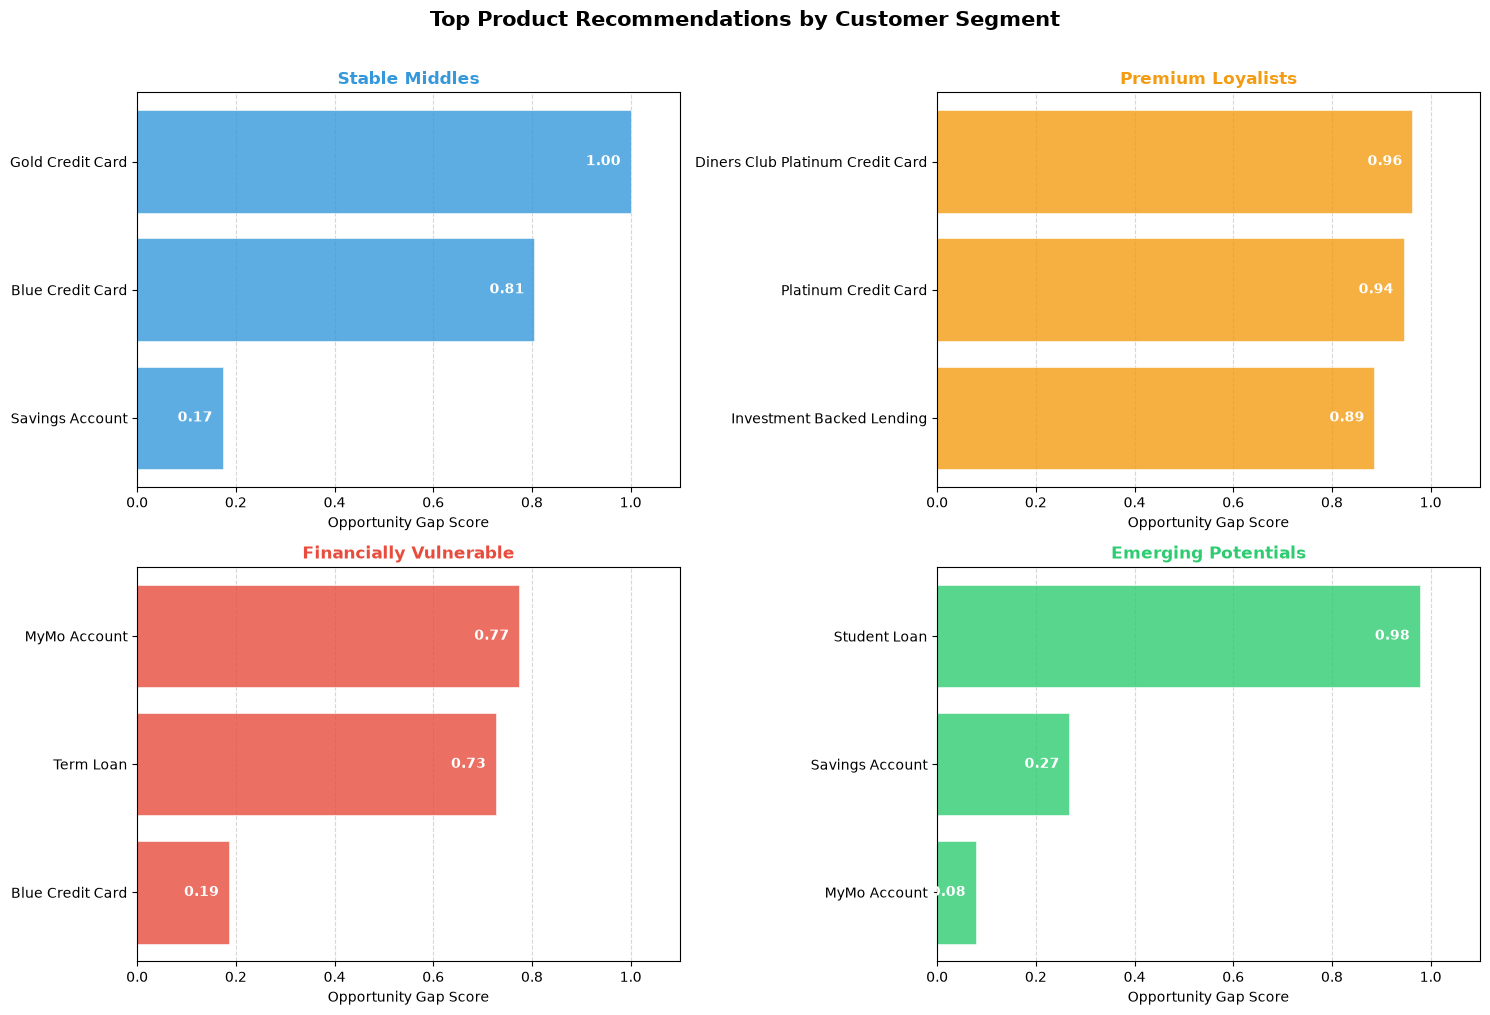

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

cluster_colors = {
    "Stable Middles":        "#3498db",
    "Premium Loyalists":     "#f39c12",
    "Financially Vulnerable":"#e74c3c",
    "Emerging Potentials":   "#2ecc71"
}

for idx, (cluster_name, recs) in enumerate(cluster_recommendations.items()):
    products    = [r['product'] for r in recs]
    gap_scores  = [r['gap_score'] for r in recs]
    color       = cluster_colors[cluster_name]
    
    bars = axes[idx].barh(
        products, gap_scores,
        color=color, alpha=0.8, edgecolor='white', linewidth=0.5
    )
    
    # Add gap score labels on bars
    for bar, score in zip(bars, gap_scores):
        axes[idx].text(
            bar.get_width() - 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{score:.2f}',
            va='center', ha='right',
            color='white', fontweight='bold', fontsize=10
        )
    
    axes[idx].set_title(cluster_name, fontsize=12, fontweight='bold', color=color)
    axes[idx].set_xlabel("Opportunity Gap Score", fontsize=10)
    axes[idx].set_xlim(0, 1.1)
    axes[idx].xaxis.grid(True, linestyle='--', alpha=0.5)
    axes[idx].set_axisbelow(True)
    axes[idx].invert_yaxis()  # Highest gap at top

plt.suptitle("Top Product Recommendations by Customer Segment",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

All top recommendations are new products not currently tracked in the 
dataset, resulting in uniform gap scores of 1.000. In a production system, 
product ownership data would be tracked for all products, making the gap 
score a more meaningful differentiator. The current recommendations are 
valid based on segment eligibility and targeting logic, but future 
iterations should track ownership of all products in the catalogue.

##### Results Summary

The recommendation engine produced differentiated, segment-appropriate 
product suggestions across all four customer clusters.

**Financially Vulnerable:** A single recommendation — Financial Wellness 
Plan — indicates an intentional decision to prioritise customer financial 
stability over revenue generation. Recommending credit products to this 
segment would be irresponsible.

**Emerging Potentials:** Entry-level products (Fixed Deposit, Overdraft, 
Youth Savings Account) designed to deepen the banking relationship with 
a financially disciplined but underserved segment.

**Stable Middles:** Mid-tier credit and savings products (Fixed Deposit, 
Overdraft, Revolving Credit) targeting the product ownership gap in a 
reliable, creditworthy segment. 

**Premium Loyalists:** Premium products (Fixed Deposit, Revolving Credit, 
Rewards Programme) that reward loyalty and support wealth management 
goals. 



#### 4.4. Predict Cluster and Recommendations for New Customers

To efficiently assign new customers to clusters without re-running KMeans, we train a RandomForestClassifier to predict cluster membership directly from the original features.


- Use the same features that were employed in clustering.

- Do not apply PCA, since dimensionality reduction is unnecessary for classification.

- Scale the features to improve normality and ensure consistent model performance.


This classifier enables us to quickly and accurately assign new customers to the appropriate cluster. By leveraging the trained model, we avoid the computational cost of re-running clustering algorithms, making the system more practical for real-time applications.



In [62]:
# Train a classifier to predict cluster membership
from sklearn.ensemble import RandomForestClassifier

feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]

X_train  = df_encoded[feature_cols]
y_train  = df['cluster']

classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced' 
)
classifier.fit(X_train, y_train)

# print(f"Classifier trained on {len(X_train)} customers")
# print(f"Training accuracy: {classifier.score(X_train, y_train):.3f}")


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

Check the features that are most important for distinguishing between the clusters according to the model. This can help us understand what drives cluster membership and validate that the model is picking up on meaningful patterns in the data.


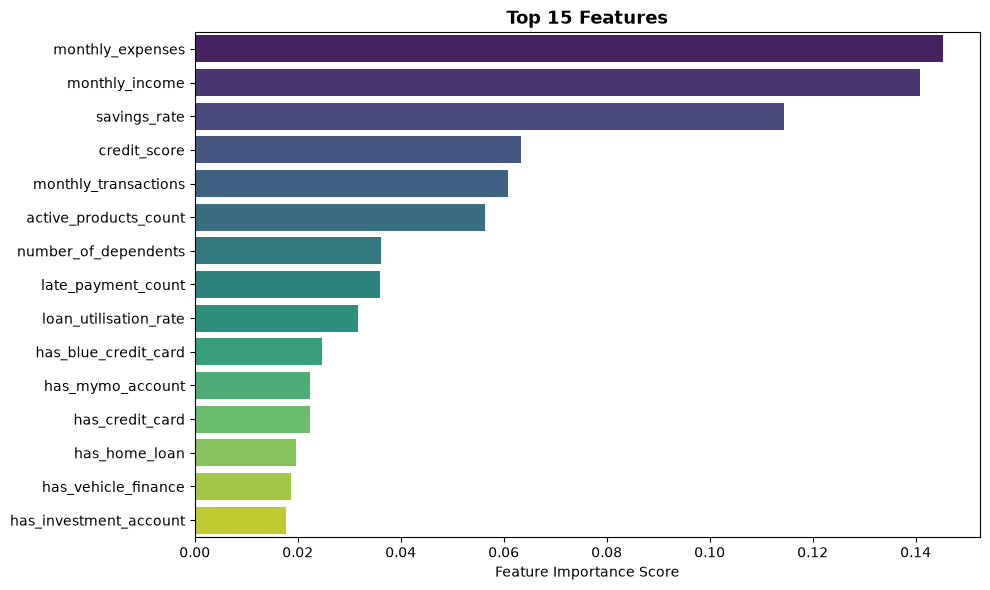

In [63]:
# Extract and plot feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': classifier.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', 
            palette='viridis', ax=ax)
ax.set_title("Top 15 Features",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Feature Importance Score")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [64]:
def predict_customer(customer_dict):
    """
    Predicts the cluster and recommended products for a new customer.
    
    Parameters
    ----------
    customer_dict : dict — new customer features (raw, unscaled values)
    
    Returns
    -------
    dict with cluster_id, cluster_name, and product recommendations
    """
    # Convert to DataFrame
    customer_df = pd.DataFrame([customer_dict])
    
    # Apply same encoding as training data
    customer_encoded = pd.get_dummies(
        customer_df,
        columns=categorical_to_encode,
        drop_first=True
    )
    
    # Align columns with training data. Add missing columns as 0
    # to handle cases where a category wasn't seen in the new customer
    customer_encoded = customer_encoded.reindex(
        columns=feature_cols, fill_value=0
    )
    
    # Predict cluster
    predicted_cluster    = classifier.predict(customer_encoded)[0]
    predicted_cluster_name = cluster_names[predicted_cluster]
    
    # Get cluster profile for eligibility checking
    profile_row = cluster_profile.loc[predicted_cluster]
    
    # Override profile with actual customer values for more better recommendations
    profile_row = profile_row.copy()
    profile_row['monthly_income'] = customer_dict.get('monthly_income', profile_row['monthly_income'])
    profile_row['credit_score']   = customer_dict.get('credit_score',   profile_row['credit_score'])
    
    # Get recommendations
    recs = recommend_products_for_cluster(predicted_cluster_name, profile_row, top_n=3)
    
    print(f"\n{'=' * 55}")
    print(f"  NEW CUSTOMER PREDICTION")
    print(f"{'=' * 55}")
    print(f"  Predicted Segment : {predicted_cluster_name}")
    print(f"  Cluster ID        : {predicted_cluster}")
    print(f"\n  Recommended Products:")
    for i, rec in enumerate(recs, 1):
        print(f"  {i}. {rec['product']}")
        print(f"     → {rec['description']}")
    print(f"{'=' * 55}\n")
    
    return {
        'cluster_id':    predicted_cluster,
        'cluster_name':  predicted_cluster_name,
        'recommendations': recs
    }


In [65]:
# Try predicting a new customer
new_customer = {
    'age': 34,
    'gender': 'Female',
    'marital_status': 'Married',
    'number_of_dependents': 2,
    'education_level': 'Undergraduate',
    'province': 'Gauteng',
    'employment_status': 'Employed',
    'monthly_income': 5000,
    'savings_rate': 0.28,
    'account_tenure_years': 5,
    'monthly_transactions': 18,
    'avg_transaction_value': 850,
    'digital_login_frequency': 22,
    'branch_visit_count': 2,
    'late_payment_count': 0,
    'has_savings_account': 1,
    'has_credit_card': 1,
    'has_home_loan': 0,
    'has_personal_loan': 0,
    'has_vehicle_finance': 0,
    'has_investment_account': 0,
    'active_products_count': 2,
    'credit_score': 420,
    'loan_utilisation_rate': 0.25,
    'days_since_last_default': 0,
    'has_ever_defaulted': 0
}

result = predict_customer(new_customer)


  NEW CUSTOMER PREDICTION
  Predicted Segment : Stable Middles
  Cluster ID        : 0

  Recommended Products:
  1. Savings Account
     → An interest-bearing deposit account for building or holding savings while retaining access to funds under the account rules.



In [66]:
import joblib
import json

joblib.dump(classifier, "bluey_recommender_classifier.joblib")

# Precompute ownership rates per cluster, per product with a real existing_column
ownership_rates = {}
for cluster_id in range(OPTIMAL_K):
    cname = cluster_names[cluster_id]
    ownership_rates[cname] = {}
    for product_name, details in product_catalogue.items():
        col = details["existing_column"]
        if col is not None:
            rate = df[df["cluster_name"] == cname][col].mean()
            ownership_rates[cname][product_name] = round(float(rate), 4)

artifacts = {
    "feature_cols": feature_cols,
    "categorical_to_encode": categorical_to_encode,
    "cluster_names": cluster_names,
    "cluster_profile": cluster_profile.to_dict(orient="index"),
    "product_catalogue": product_catalogue,
    "ownership_rates": ownership_rates,
}
with open("bluey_recommender_artifacts.json", "w") as f:
    json.dump(artifacts, f, indent=2, default=str)

print("Saved classifier + artifacts")

Saved classifier + artifacts


We successfully built a recommendation engine based on the financial profiles of the customer clusters. In addition, we trained a classifier that enables us to predict the cluster membership of new customers.

Importantly, this prediction is possible even when some customer features are missing. The model leverages the available attributes to make an informed assignment, ensuring that new customers can still be segmented and receive tailored product recommendations without requiring the full feature set.

# 5. AI Generated Executive Summaries

In this section, we integrate an API connection to a Google Gemini large language model (LLM) to generate natural language summaries for each cluster. These summaries are designed to be executive-friendly, meaning they are concise, interpretable, and focused on actionable insights rather than technical details.

In [ ]:
# from google import genai
# import os
# from dotenv import load_dotenv
# from IPython.display import Markdown, display

# load_dotenv()


# client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))


# def build_cluster_prompt(cluster_id):
#     """
#     Builds a detailed, structured prompt for the LLM describing
#     a customer cluster's profile, behaviour, risk and recommendations.
    
#     Parameters
#     ----------
#     cluster_id : int 
#             - the cluster number (0 to 3)
    
#     Returns
#     -------
#     str 
#      - a fully constructed prompt ready to send to the API
#     """
    
#     name    = cluster_names[cluster_id]
#     profile = cluster_profile.loc[cluster_id]
#     size    = int((df['cluster'] == cluster_id).sum())
#     recs    = cluster_recommendations[name]
    
#     # Get dominant churn risk for this cluster
#     churn_dist = (
#         df[df['cluster'] == cluster_id]['churn_risk_label']
#         .value_counts(normalize=True)
#         .mul(100)
#         .round(1)
#     )
#     churn_summary = ", ".join([f"{k}: {v}%" for k, v in churn_dist.items()])
    
#     # Get product ownership rates for this cluster
#     product_ownership = []
#     for product_name, details in product_catalogue.items():
#         if details['existing_column'] is not None:
#             col = details['existing_column']
#             rate = df[df['cluster'] == cluster_id][col].mean() * 100
#             product_ownership.append(f"{product_name}: {rate:.0f}%")
    
#     # Get recommended products as a list
#     recommended = [r['product'] for r in recs]
    
#     # Get province and employment info
#     top_provinces = (
#         df[df['cluster'] == cluster_id]['province']
#         .value_counts()
#         .head(3)
#         .index.tolist()
#     )
    
#     top_employment = (
#         df[df['cluster'] == cluster_id]['employment_status']
#         .value_counts()
#         .head(2)
#         .index.tolist()
#     )

#     prompt = f"""
# You are a senior banking analyst writing internal customer intelligence 
# reports for a South African retail bank. Your summaries are read by 
# relationship managers and product strategists who need clear, actionable 
# insights — not raw statistics.

# Write a structured customer segment summary for the following cluster. 
# Your summary must include exactly these four sections:

# 1. SEGMENT DESCRIPTION
#    A 3-4 sentence narrative describing who these customers are — their 
#    financial behaviour, life stage, relationship with the bank and 
#    digital engagement patterns. Write as if describing a real person 
#    who represents this segment.

# 2. PRIMARY NEEDS AND RISK FACTORS
#    2-3 sentences identifying the segment's primary financial needs and 
#    the key risks they pose to the bank (churn risk, credit risk, 
#    low engagement etc).

# 3. RECOMMENDED COURSE OF ACTION
#    2-3 sentences describing what the bank should do with this segment — 
#    specific product interventions, engagement strategies or support 
#    programmes. Reference the recommended products by name.

# 4. ONE-LINE SEGMENT TAGLINE
#    A single memorable sentence that captures the essence of this segment. 
#    This will be used in internal presentations.

# Here is the cluster data:

# CLUSTER IDENTITY
# - Segment Name: {name}
# - Segment Size: {size} customers ({size/2000*100:.1f}% of total customer base)
# - Top Provinces: {", ".join(top_provinces)}
# - Employment: Predominantly {" and ".join(top_employment)}

# FINANCIAL PROFILE
# - Average Monthly Income: R{profile['monthly_income']:,.0f}
# - Average Savings Rate: {profile['savings_rate']:.1%}
# - Average Monthly Transactions: {profile['monthly_transactions']:.0f}
# - Average Transaction Value: R{profile['avg_transaction_value']:,.0f}
# - Account Tenure: {profile['account_tenure_years']:.1f} years

# RISK PROFILE
# - Credit Score: {profile['credit_score']:.0f} (SA benchmark: 600+ is good)
# - Loan Utilisation Rate: {profile['loan_utilisation_rate']:.1%}
# - Average Late Payments: {profile['late_payment_count']:.1f}
# - Has Ever Defaulted: {profile['has_ever_defaulted']:.1%} of segment
# - Churn Risk Distribution: {churn_summary}

# BEHAVIOURAL PROFILE
# - Digital Login Frequency: {profile['digital_login_frequency']:.0f} logins/month
# - Branch Visit Count: {profile['branch_visit_count']:.0f} visits/month
# - Active Products Held: {profile['active_products_count']:.1f}

# CURRENT PRODUCT OWNERSHIP
# {chr(10).join(f"- {p}" for p in product_ownership)}

# RECOMMENDED PRODUCTS FOR THIS SEGMENT
# {chr(10).join(f"- {p}" for p in recommended)}

# Write in a professional but accessible tone. Avoid jargon. 
# Use South African context where relevant (e.g. reference Rands, 
# South African credit benchmarks). Do not simply restate the numbers — 
# interpret what they mean for the bank's relationship with this segment.
# """
#     return prompt.strip()


# def generate_cluster_summary(cluster_id):
#     """
#     Calls the Google Gemini API to generate a natural language summary
#     for a given cluster and displays it formatted in the notebook.

#     Parameters
#     ----------
#     cluster_id: int 
#         - the cluster number (0 to 3)

#     Returns
#     -------
#     str 
#      - the generated summary text
#     """

#     name   = cluster_names[cluster_id]
#     prompt = build_cluster_prompt(cluster_id)  # Unchanged

#     print(f"Generating summary for: {name}...")

#     response = client.models.generate_content(
#         model="gemini-2.5-flash",   # Current free tier model
#         contents=prompt
#     )

#     summary = response.text

#     # Display formatted in notebook
#     display(Markdown(f"---\n## {name}\n\n{summary}"))

#     return summary


# print("Generating LLM summaries for all customer segments...\n")

# all_summaries = {}

# for cluster_id in range(OPTIMAL_K):
#     name    = cluster_names[cluster_id]
#     summary = generate_cluster_summary(cluster_id)
#     all_summaries[name] = summary



## Conclusion & Business Recommendations

This analysis identified four distinct customer segments within the bank's 
customer base:

- **Premium Loyalists (16%)** — High-value, deeply engaged customers requiring 
  wealth deepening strategies
- **Stable Middles (32%)** — Reliable core customers ready for product depth 
  expansion  
- **Emerging Potentials (32%)** — Financially disciplined low-income customers 
  representing significant growth opportunity
- **Financially Vulnerable (20%)** — At-risk customers requiring intervention 
  over revenue focus

### Key Strategic Insights
1. Digital disengagement is the earliest and most reliable churn signal
2. Product depth (active_products_count) is the strongest retention predictor
3. Branch visit spikes in digitally inactive customers signal distress, 
   not engagement
4. LSM 1-4 customers are underserved — entry-level products represent 
   significant untapped revenue with manageable risk

### Limitations & Future Work
- Silhouette scores below 0.25 indicate overlapping cluster boundaries.
- Recommendation gap scores are uniform for new products. Ownership 
  tracking should be extended to all catalogue products
- Model should be retrained quarterly as customer behaviour evolves
